In [1]:
import os
import uproot
import ROOT
import awkward as ak
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import vector         # for 4-vector operations (vector.awkward)
awk = vector.awkward
import pandas as pd
from hist import Hist, Stack
import mplhep as hep
from normalisation import getLumi
from cycler import cycler
# Load CMS style including color-scheme
hep.style.use("CMS")
plt.rcParams["axes.prop_cycle"] = cycler(
    color=[
        "#3f90da",
        "#ffa90e",
        "#bd1f01",
        "#94a4a2",
        "#832db6",
        "#a96b59",
        "#e76300",
        "#b9ac70",
        "#717581",
        "#92dadd",
    ]
)
plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['font.size'] = 12


In [7]:
# Load ROOT file
filepaths_hist = [
    "outputfiles/NMSSM_MX-300_MY-60-histograms.root",
    "outputfiles/NMSSM_MX-300_MY-70-histograms.root",
    "outputfiles/NMSSM_MX-300_MY-80-histograms.root",
    "outputfiles/NMSSM_MX-300_MY-90-histograms.root",
    "outputfiles/NMSSM_MX-300_MY-95-histograms.root",
    "outputfiles/NMSSM_MX-300_MY-100-histograms.root",
    "outputfiles/NMSSM_MX-300_MY-125-histograms.root",
    "outputfiles/NMSSM_MX-300_MY-150-histograms.root"
    
]
filepaths_trees = [
    "outputfiles/NMSSM-XtoYH-MX-300-MY-60-trees.root",
    "outputfiles/NMSSM-XtoYH-MX-300-MY-70-trees.root",
    "outputfiles/NMSSM-XtoYH-MX-300-MY-80-trees.root",
    # "outputfiles/NMSSM_MX-300-MY-90-trees.root",
    # "outputfiles/NMSSM_MX-300-MY-95-trees.root",
    # "outputfiles/NMSSM_MX-300-MY-100-trees.root",
    # "outputfiles/NMSSM_MX-300-MY-125-trees.root",
    # "outputfiles/NMSSM_MX-300-MY-150-trees.root",
]

#CHECK ORDER
filepaths_bkg_hist=["outputfiles/GJetPt20To40-histograms.root", "outputfiles/GGJets_MGG-80-histograms.root", "outputfiles/GJetPt40-histograms.root"]
filepaths_bkg_trees=["outputfiles/GGJets_MGG-80-trees.root", "outputfiles/GJetPt20To40-trees.root",  "outputfiles/GJetPt40-trees.root"]

files_h = [uproot.open(path) for path in filepaths_hist]
files_t = [uproot.open(path) for path in filepaths_trees]
files_bkg_h = [uproot.open(path) for path in filepaths_bkg_hist]
files_bkg_t = [uproot.open(path) for path in filepaths_bkg_trees]

FileNotFoundError: [Errno 2] No such file or directory: '/eos/home-b/bsinghal/analysis/hhbbgg_AwkwardAnalyzer/outputfiles/NMSSM_MX-300_MY-60-histograms.root'

In [4]:
print(files_t)

[<ReadOnlyDirectory '/' at 0x7fbf630c60b0>, <ReadOnlyDirectory '/' at 0x7fbf630c6470>, <ReadOnlyDirectory '/' at 0x7fbf630c6830>, <ReadOnlyDirectory '/' at 0x7fbf630c6bf0>, <ReadOnlyDirectory '/' at 0x7fbf630c6fb0>, <ReadOnlyDirectory '/' at 0x7fbf630c7370>, <ReadOnlyDirectory '/' at 0x7fbf630c7730>, <ReadOnlyDirectory '/' at 0x7fbf630c7af0>]


In [8]:
file = uproot.open("outputfiles/NMSSM_MX-300_MY-60-trees.root")

In [9]:
# Check what's inside
#print(file.keys())

for key in file.keys():
    print(" ", key)

  processed_events;1
  NOTAG_merged;1
  NOTAG_merged/preselection;1
  NOTAG_merged/selection;1
  NOTAG_merged/bbgg;1
  NOTAG_merged/srbbgg;1
  NOTAG_merged/srbbggMET;1
  NOTAG_merged/crantibbgg;1
  NOTAG_merged/crbbantigg;1
  NOTAG_merged/crantibbantigg;1
  NOTAG_merged/sideband;1
  NOTAG_merged/idmva_sideband;1
  NOTAG_merged/idmva_presel;1


In [10]:
print("\nKeys inside SampleName/Region:")
print(file["NOTAG_merged/srbbgg"].keys())


Keys inside SampleName/Region:
['run', 'lumi', 'event', 'puppiMET_pt', 'puppiMET_phi', 'puppiMET_phiJERDown', 'puppiMET_phiJERUp', 'puppiMET_phiJESDown', 'puppiMET_phiJESUp', 'puppiMET_phiUnclusteredDown', 'puppiMET_phiUnclusteredUp', 'puppiMET_ptJERDown', 'puppiMET_ptJERUp', 'puppiMET_ptJESDown', 'puppiMET_ptJESUp', 'puppiMET_ptUnclusteredDown', 'puppiMET_ptUnclusteredUp', 'puppiMET_sumEt', 'lead_pho_pt', 'lead_pho_eta', 'lead_pho_phi', 'sublead_pho_pt', 'sublead_pho_eta', 'sublead_pho_phi', 'lead_bjet_pt', 'lead_bjet_eta', 'lead_bjet_phi', 'sublead_bjet_pt', 'sublead_bjet_eta', 'sublead_bjet_phi', 'dibjet_mass', 'diphoton_mass', 'bbgg_mass', 'dibjet_pt', 'diphoton_pt', 'bbgg_pt', 'bbgg_eta', 'bbgg_phi', 'DeltaPhi_j1MET', 'DeltaPhi_j2MET', 'Res_chi_t0', 'Res_chi_t1', 'lepton1_mvaID', 'lepton1_pt', 'lepton1_pfIsoId', 'n_jets', 'weight_central', 'dibjet_eta', 'dibjet_phi', 'diphoton_eta', 'diphoton_phi', 'lead_bjet_PNetB', 'sublead_bjet_PNetB', 'pholead_PtOverM', 'phosublead_PtOverM', 

In [11]:
def get_histogram(file_name, hist_name, hist_label=None):
    histogram = Hist(file_name[hist_name])
    if hist_label is not None:
        histogram.name = hist_label
    return histogram

In [12]:
tree = file["NOTAG_merged/srbbgg"]

SIGNAL PLOTS

  NMSSM_MX-300_MY-60             →     5716 events
  NMSSM_MX-300_MY-70             →     5513 events
  NMSSM_MX-300_MY-80             →     5708 events
  NMSSM_MX-300_MY-90             →     5951 events
  NMSSM_MX-300_MY-95             →     5976 events
  NMSSM_MX-300_MY-100            →     6177 events
  NMSSM_MX-300_MY-125            →     7309 events
  NMSSM_MX-300_MY-150            →     8092 events


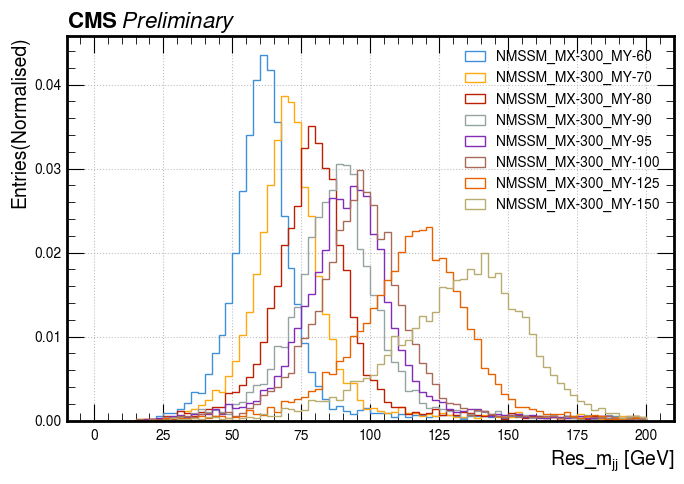

  NMSSM_MX-300_MY-60             →     5716 events
  NMSSM_MX-300_MY-70             →     5513 events
  NMSSM_MX-300_MY-80             →     5708 events
  NMSSM_MX-300_MY-90             →     5951 events
  NMSSM_MX-300_MY-95             →     5976 events
  NMSSM_MX-300_MY-100            →     6177 events
  NMSSM_MX-300_MY-125            →     7309 events
  NMSSM_MX-300_MY-150            →     8092 events


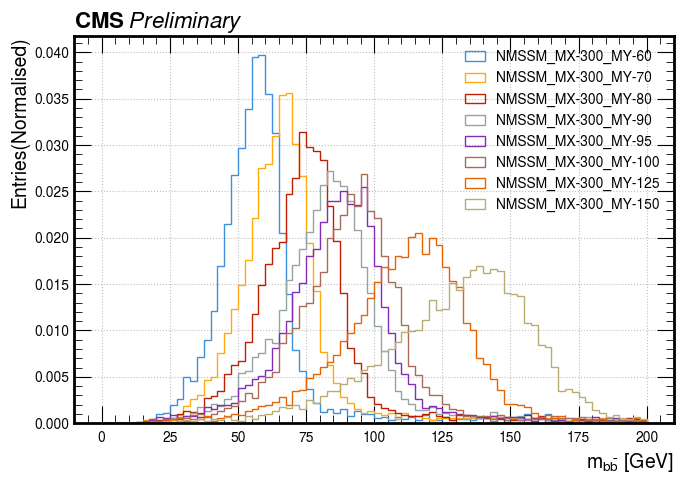

In [3]:
#DIBJET_mass and Res_Dijet_mass_DNNreg

branch_name = ["Res_dijet_mass_DNNreg", "dibjet_mass"]  
xlabel = [r"Res_$m_{jj}$ [GeV]",r"$m_{b\bar{b}}$ [GeV]"]#, r"M_{bbgg}[GeV]", r"M_{\Widetilde{X}}"]  
# branch_name = "Res_dijet_mass_DNNreg"
for branch, dist in zip(branch_name, xlabel):
    for path in filepaths_trees:
        sample_name = os.path.basename(path).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        with uproot.open(path) as f:
            # Access the TTree
            tree = f["NOTAG_merged/bbgg"]
            
            # print(tree.keys())
            # Get dibjet_mass branch as a NumPy array
            dibjet_mass = tree[f"{branch}"].array(library="np")
            w = tree["weight_srbbgg"].array(library="np")
            # Plot histogram directly
            plt.hist(dibjet_mass, bins=80, range=(0,200), histtype="step", density=True, label=path.split("/")[-1].replace("-trees.root", ""))
        # print(ak.num(tree[f"{branch}"].array()))
        
        n_events = len(dibjet_mass)
        print(f"  {sample_name:<30} → {n_events:>8} events")
    
    plt.grid()
    plt.xlabel(dist, fontsize=14)
    plt.ylabel("Entries(Normalised)", fontsize=14)
    # plt.yscale("log")
    plt.legend()
    plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
    plt.tight_layout()
    plt.show()




SIgnal PLOTS for reduced mass

  NMSSM_MX-300_MY-60             →     5716 events
  NMSSM_MX-300_MY-70             →     5513 events
  NMSSM_MX-300_MY-80             →     5708 events
  NMSSM_MX-300_MY-90             →     5951 events
  NMSSM_MX-300_MY-95             →     5976 events
  NMSSM_MX-300_MY-100            →     6177 events
  NMSSM_MX-300_MY-125            →     7309 events
  NMSSM_MX-300_MY-150            →     8092 events


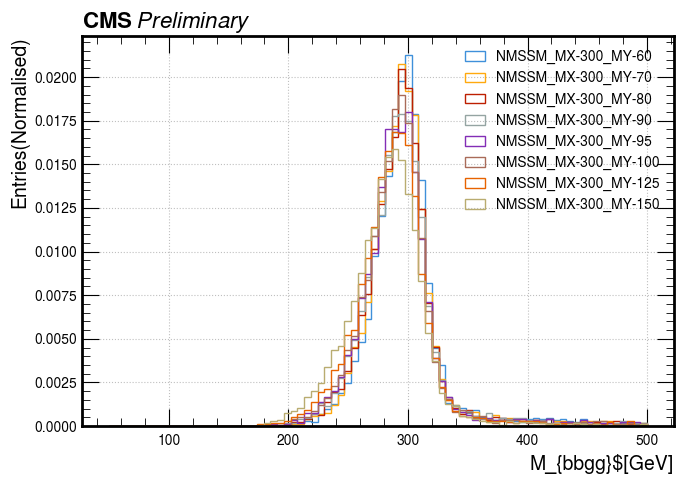

  NMSSM_MX-300_MY-60             →     5716 events
  NMSSM_MX-300_MY-70             →     5513 events
  NMSSM_MX-300_MY-80             →     5708 events
  NMSSM_MX-300_MY-90             →     5951 events
  NMSSM_MX-300_MY-95             →     5976 events
  NMSSM_MX-300_MY-100            →     6177 events
  NMSSM_MX-300_MY-125            →     7309 events
  NMSSM_MX-300_MY-150            →     8092 events


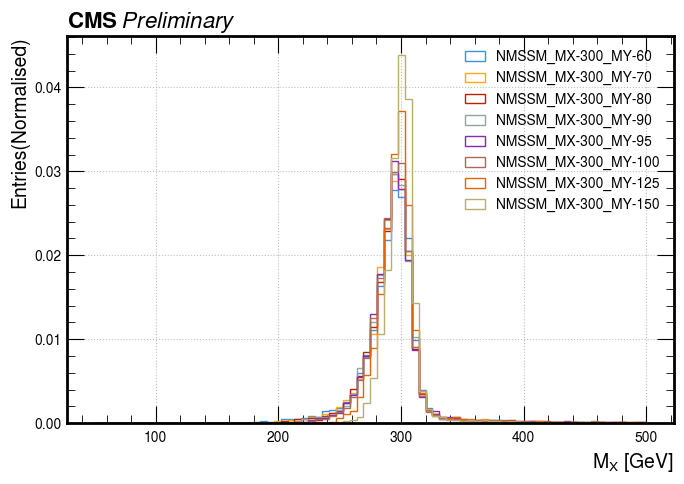

In [14]:
branch_name = ["bbgg_mass", "reduced_MX"]  
xlabel = [r"M_{bbgg}$[GeV]",r"$M_X$ [GeV]"]#, r"M_{bbgg}[GeV]", r"M_{\Widetilde{X}}"]  
# branch_name = "Res_dijet_mass_DNNreg"
for branch, dist in zip([0,1], xlabel):    
    distribution = [1,2]
    distribution[0] = []
    distribution[1] = []
    for path in filepaths_trees:
        sample_name = os.path.basename(path).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        with uproot.open(path) as f:
            # Access the TTree
            tree = f["NOTAG_merged/bbgg"]
            bbgg_mass = tree["bbgg_mass"].array(library="np")
            diphoton_mass = tree["diphoton_mass"].array(library="np")
            dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
            reduced_MX = bbgg_mass - (diphoton_mass - 125) - (dijet_mass - Y_Mass)
            distribution[0] = bbgg_mass
            distribution[1] = reduced_MX
            # print(tree.keys())
            # Get dibjet_mass branch as a NumPy array
            # dibjet_mass = tree[f"{branch}"].array(library="np")
            w = tree["weight_srbbgg"].array(library="np")
            # Plot histogram directly
        plt.hist(distribution[branch], bins=80, range=(50,500), histtype="step", density=True, label=path.split("/")[-1].replace("-trees.root", ""))
        # print(ak.num(tree[f"{branch}"].array()))
        
        n_events = len(bbgg_mass)
        print(f"  {sample_name:<30} → {n_events:>8} events")

    plt.grid()
    plt.xlabel(dist, fontsize=14)
    plt.ylabel("Entries(Normalised)", fontsize=14)
    # plt.yscale("log")
    plt.legend()
    plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
    plt.tight_layout()
    plt.show()


  NMSSM-XtoYH-MX-300-MY-60       →     5716 events


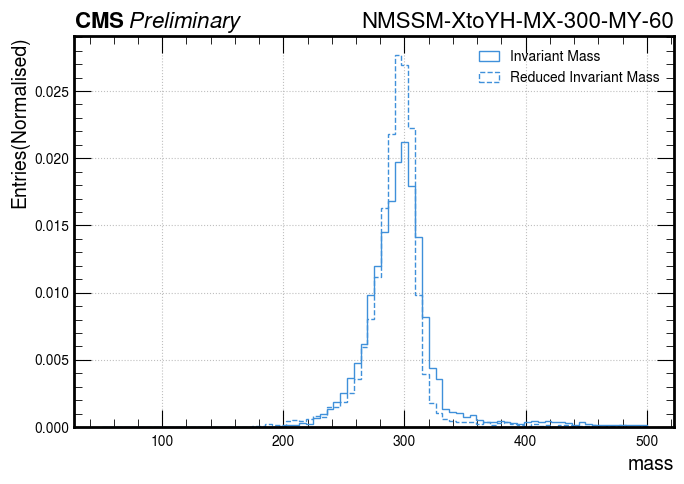

  NMSSM-XtoYH-MX-300-MY-70       →     5510 events


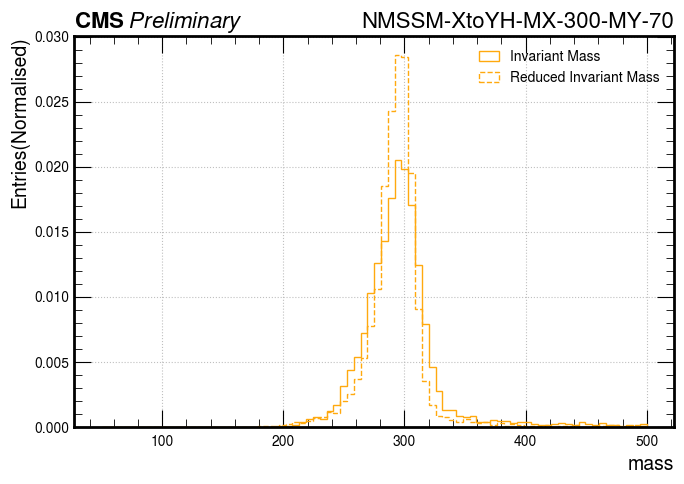

  NMSSM-XtoYH-MX-300-MY-80       →     5714 events


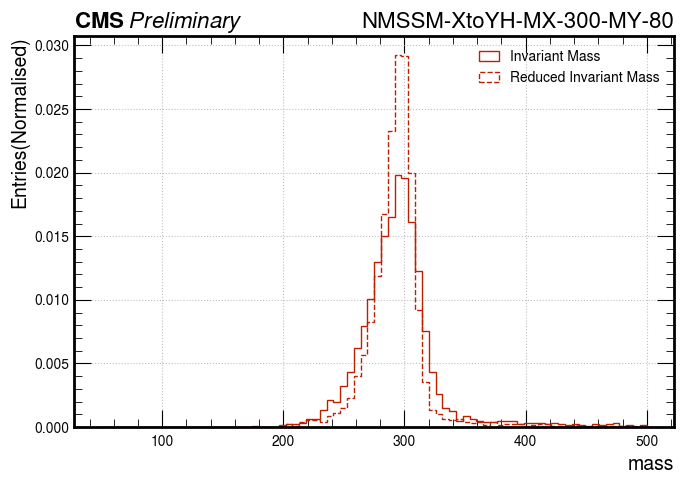

In [12]:
#Invarinat Mass and Reduced Invariant Mass
color=[
        "#3f90da",
        "#ffa90e",
        "#bd1f01",
        "#94a4a2",
        "#832db6",
        "#a96b59",
        "#e76300",
        "#b9ac70",
        "#717581",
        "#92dadd",
    ]
branch_name = ["bbgg_mass"]  
xlabel = [r"$M_{b\bar{b}\gamma\gamma}$ [GeV]"]  
# branch_name = "Res_dijet_mass_DNNreg"
for path,c in zip(filepaths_trees, color): 
    line_handles = []  # to store custom line handles for legend
    line_labels = []   
    for branch, dist in zip(branch_name, xlabel):
        sample_name = os.path.basename(path).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM-XtoYH-MX-300-MY-","" ))
        with uproot.open(path) as f:
            # Access the TTree
            tree = f["NOTAG_merged/bbgg"]
            # Get dibjet_mass branch as a NumPy array
            bbgg_mass = tree[f"{branch}"].array(library="np")
            diphoton_mass = tree["diphoton_mass"].array(library="np")
            dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
            reduced_MX = bbgg_mass - (diphoton_mass - 125) - (dijet_mass - Y_Mass)
            # Plot histogram directly

            # plt.hist(bbgg_mass, bins=80, range=(50,500), histtype="step", label= "Invariant Mass")
            # plt.hist(reduced_MX, bins=80, range=(50,500), histtype="step", label= "Reduced Invariant Mass")
        # print(ak.num(tree[f"{branch}"].array()))
        n,bins, patches = plt.hist(bbgg_mass, bins=80, range=(50,500), histtype='step',density=True, label= "Invariant Mass", color = c )
        n,bins, patches = plt.hist(reduced_MX, bins=80, range=(50,500), histtype='step', density=True, label= "Reduced Invariant Mass", color = c )
        # plt.hist(summed_cut, bins=55, range=(100,500), histtype='step', label= f"{ll:.1f}<{dist}<{ul:.1f}" )
    styles = ['--', '-']
    for p, s in zip(patches, styles):
        p.set_linestyle(s)
        line_handles.append(p)
        # line_labels.append(f"{dist}: ({ll:.1f}, {ul:.1f}), (Events: {ak.count(diphoton_arrays)})")
    n_events = len(bbgg_mass)
    print(f"  {sample_name:<30} → {n_events:>8} events")
    plt.grid()
    plt.xlabel("mass", fontsize=14)
    plt.ylabel("Entries(Normalised)", fontsize=14)
    # plt.yscale("log")
    plt.legend()
    plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
    plt.title(path.split("/")[-1].replace("-trees.root", ""), loc='right', fontsize=16)
    plt.tight_layout()
    plt.show()

  NMSSM_MX-300_MY-60             →     5716 events


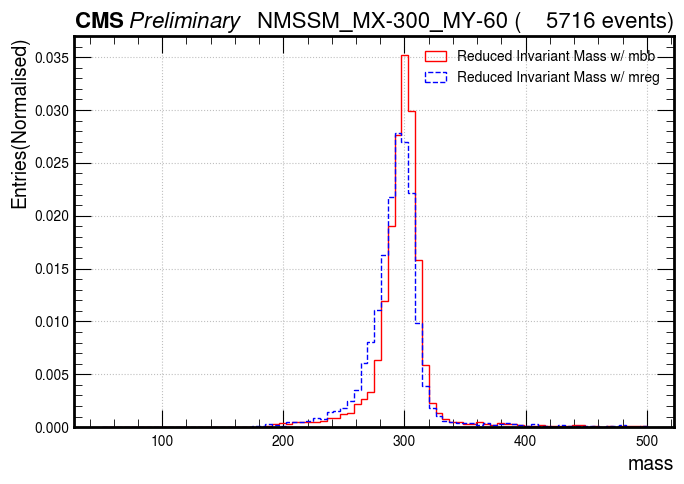

  NMSSM_MX-300_MY-70             →     5513 events


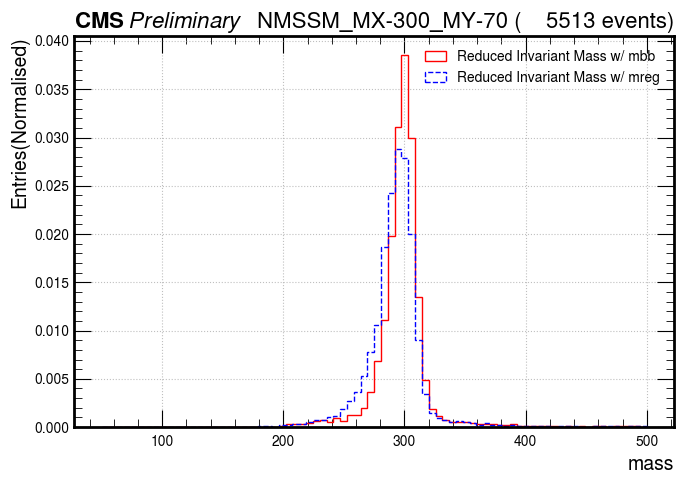

  NMSSM_MX-300_MY-80             →     5708 events


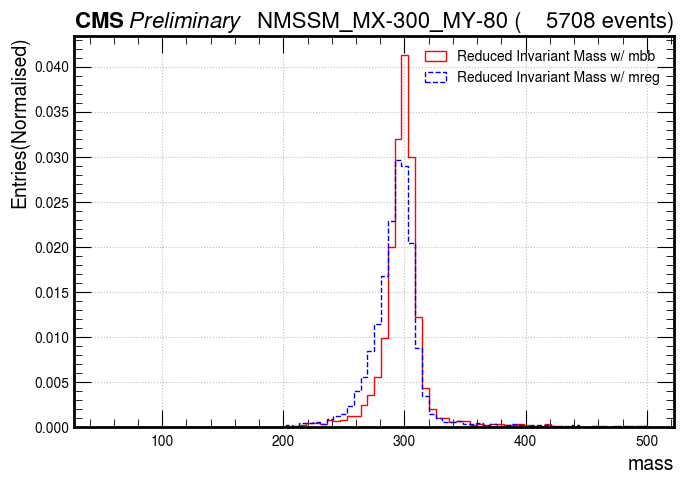

  NMSSM_MX-300_MY-90             →     5951 events


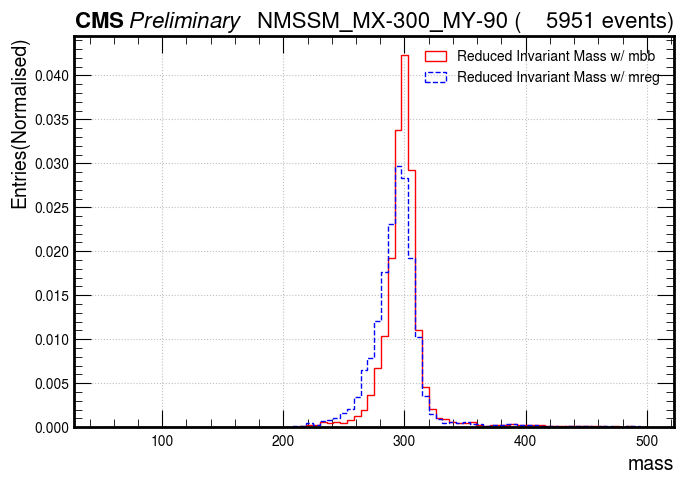

  NMSSM_MX-300_MY-95             →     5976 events


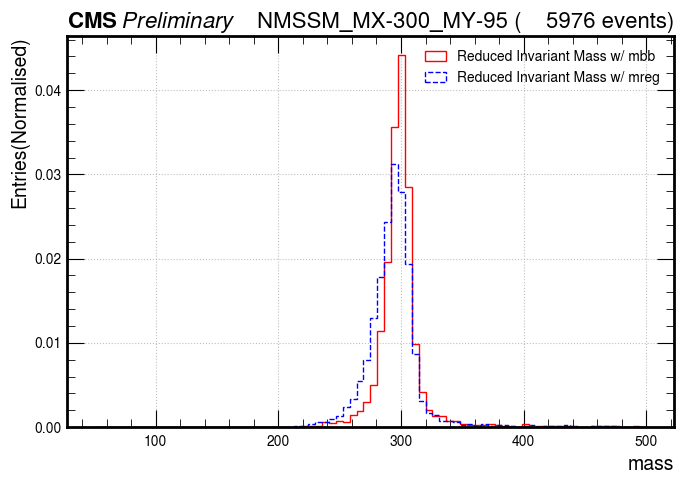

  NMSSM_MX-300_MY-100            →     6177 events


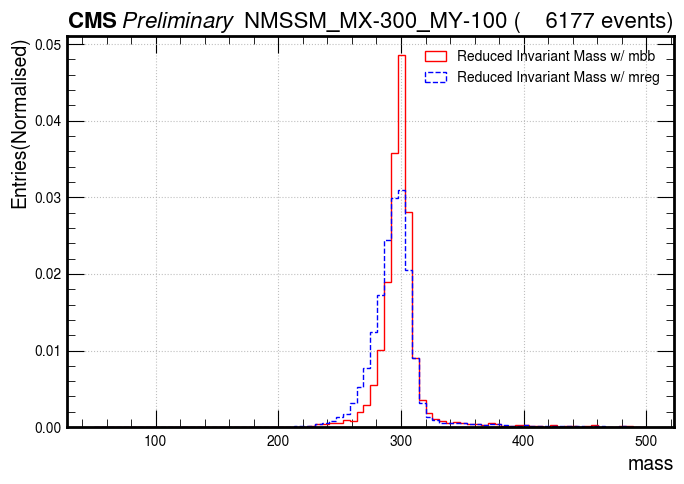

  NMSSM_MX-300_MY-125            →     7309 events


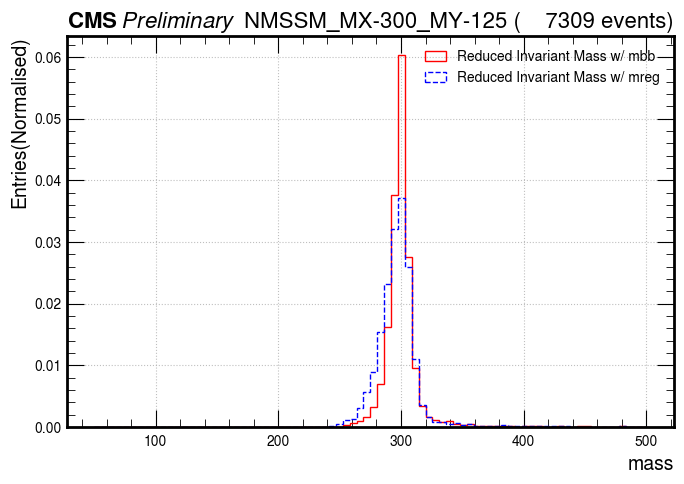

  NMSSM_MX-300_MY-150            →     8092 events


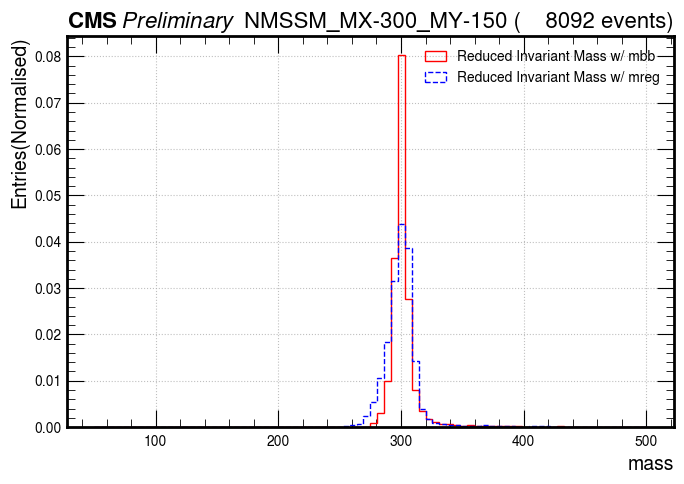

In [7]:
#REDUCED INVARIANT MASSS CALCULATED WITH DIBJET MASS AND REG_DIJET MASS
color=[
        "#3f90da",
        "#ffa90e",
        "#bd1f01",
        "#94a4a2",
        "#832db6",
        "#a96b59",
        "#e76300",
        "#b9ac70",
        "#717581",
        "#92dadd",
    ]
branch_name = ["bbgg_mass"]  
xlabel = [r"$M_{b\bar{b}\gamma\gamma}$ [GeV]"]  
# branch_name = "Res_dijet_mass_DNNreg"
for path,c in zip(filepaths_trees, color): 
    line_handles = []  # to store custom line handles for legend
    line_labels = []   
    for branch, dist in zip(branch_name, xlabel):
        sample_name = os.path.basename(path).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        with uproot.open(path) as f:
            # Access the TTree
            tree = f["NOTAG_merged/bbgg"]
            # Get dibjet_mass branch as a NumPy array
            bbgg_mass = tree[f"{branch}"].array(library="np")
            diphoton_mass = tree["diphoton_mass"].array(library="np")
            dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
            dibjet_mass = tree["dibjet_mass"].array(library="np")
            reduced_MX_mbb = bbgg_mass - (diphoton_mass - 125) - (dibjet_mass - Y_Mass)
            reduced_MX_mreg = bbgg_mass - (diphoton_mass - 125) - (dijet_mass - Y_Mass)
            # Plot histogram directly

            # plt.hist(bbgg_mass, bins=80, range=(50,500), histtype="step", label= "Invariant Mass")
            # plt.hist(reduced_MX, bins=80, range=(50,500), histtype="step", label= "Reduced Invariant Mass")
        # print(ak.num(tree[f"{branch}"].array()))
        # n,bins, patches = plt.hist(bbgg_mass, bins=80, range=(50,500), histtype='step',density=True, label= "Invariant Mass", color = c )
        n,bins, patches = plt.hist(reduced_MX_mbb, bins=80, range=(50,500), histtype='step', density=True, label= "Reduced Invariant Mass w/ mbb", color = 'r' )
        n,bins, patches = plt.hist(reduced_MX_mreg, bins=80, range=(50,500), histtype='step', density=True, label= "Reduced Invariant Mass w/ mreg", color = 'b' )

        # plt.hist(summed_cut, bins=55, range=(100,500), histtype='step', label= f"{ll:.1f}<{dist}<{ul:.1f}" )
    styles = ['--', '-']
    for p, s in zip(patches, styles):
        p.set_linestyle(s)
        line_handles.append(p)
        # line_labels.append(f"{dist}: ({ll:.1f}, {ul:.1f}), (Events: {ak.count(diphoton_arrays)})")
    n_events = len(bbgg_mass)
    print(f"  {sample_name:<30} → {n_events:>8} events")
    plt.grid()
    plt.xlabel("mass", fontsize=14)
    plt.ylabel("Entries(Normalised)", fontsize=14)
    # plt.yscale("log")
    plt.legend()
    plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
    plt.title(path.split("/")[-1].replace("-trees.root", "")+f" ({n_events:>8} events)", loc='right', fontsize=16)
    plt.tight_layout()
    plt.show()

Double Crystal Ball Fit For Signal For dibjet and reg_dijet nmass

In [4]:
branch_name = ["Res_dijet_mass_DNNreg", "dibjet_mass"]   # or dijet_mass
xlabel = [r"Res_$M_{jj}$ [GeV]",r"$M_{b\bar{b}}$ [GeV]"]
hist_bins = 55
hist_range = (0.0, 180.0)

# Choose fit mode: "binned" or "unbinned"
fit_mode = "binned"   # or "unbinned"
# ------------------------------------------------
fit_results = {}
# Loop over samples
for branch, dist in zip(branch_name, xlabel):
    fit_results[branch]={}
    for fpath in filepaths_trees:
        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        print(f"\nProcessing {sample_name} ...")

        # ----- read array from TTree using uproot -----
        with uproot.open(fpath) as f:
            tree = f["NOTAG_merged/bbgg"]      # adjust if different path
            arr = tree[branch].array(library="np")
        # filter NaN/inf just in case
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            print("  no finite entries -> skipping")
            continue

        # ----- build a TH1D from the numpy array (for plotting / binned fit) -----
        nbins = hist_bins
        xmin, xmax = hist_range
        th_name = f"th_{sample_name}"
        th = ROOT.TH1D(th_name, f"{sample_name};{branch};Events", nbins, xmin, xmax)
        th.Sumw2()
        for v in arr:
            th.Fill(float(v))

        # get quick stats for initial parameter guesses
        # Guess_range=[Y_Mass-25, Y_Mass+25]
        mean_guess = th.GetMean() if th.GetEntries() > 0 else np.mean(arr) if arr.size else 0.0
        rms_guess  = th.GetRMS()  if th.GetEntries() > 0 else np.std(arr) if arr.size else 1.0
        amp_guess  = th.GetMaximum()

        # ----- RooFit variables and PDFs -----
        x = ROOT.RooRealVar("x", "mass", xmin, xmax)

        mean = ROOT.RooRealVar("mean", "mean", mean_guess, xmin, xmax)
        sigma = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess), 0.01, 50.0)
        sigmaR = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess*1.2), 0.01, 50.0)
        sigmaL = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess*0.8), 0.01, 50.0)


        # left-tail CB parameters (alpha positive)
        alphaL = ROOT.RooRealVar("alphaL", "alphaL", 1.5, 0.001, 10.0)
        nL     = ROOT.RooRealVar("nL", "nL", 50.0, 0.1, 250.0)

        # right-tail CB parameters (alpha negative)
        alphaR = ROOT.RooRealVar("alphaR", "alphaR", -1.0, -10.0, -0.001)   # negative initial to indicate right tail
        nR     = ROOT.RooRealVar("nR", "nR", 2.0, 0.1, 250.0)

        # Fraction parameter: fraction of left CB
        frac = ROOT.RooRealVar("frac", "fraction leftCB", 0.5, 0.0, 1.0)

        # Create RooCrystalBall (or RooCBShape) components
        cb_left  = ROOT.RooCrystalBall("cbL", "cb left", x, mean, sigmaL, alphaL, nL)
        cb_right = ROOT.RooCrystalBall("cbR", "cb right", x, mean, sigmaR, alphaR, nR)
        

        # Combine into a double-sided CB via addition
        # doubleCB = ROOT.RooAddPdf("doubleCB", "double Crystal Ball", ROOT.RooArgList(cb_left, cb_right), ROOT.RooArgList(frac))
        doubleCB= ROOT.RooCrystalBall("DCB", "DoubleCB", x, mean, sigma, alphaL, nL, alphaR, nR)
        # ----- prepare data for fit -----
        if fit_mode.lower() == "unbinned":
            # Build unbinned RooDataSet from numpy array
            data = ROOT.RooDataSet(f"data_{sample_name}", f"data_{sample_name}", ROOT.RooArgSet(x))
            for val in arr:
                x.setVal(float(val))
                data.add(ROOT.RooArgSet(x))
            data_arg = data
            print(f"  Unbinned dataset entries: {data.numEntries()}")
        else:
            # Binned: make RooDataHist from TH1
            datahist = ROOT.RooDataHist(f"datahist_{sample_name}", f"datahist_{sample_name}", ROOT.RooArgList(x), th)
            data_arg = datahist
            print(f"  Binned hist entries (TH1): {th.GetEntries()}  bins: {th.GetNbinsX()}")

        # ----- Fit -----
        fit_opts = [ROOT.RooFit.Save(True)]
        # For binned fits with weighted hist, include SumW2Error
        if fit_mode.lower() == "binned":
            fit_result = doubleCB.fitTo(data_arg, ROOT.RooFit.Save(True), ROOT.RooFit.SumW2Error(False))
        else:
            fit_result = doubleCB.fitTo(data_arg, ROOT.RooFit.Save(True))
        fitted_par = [mean, sigma, alphaL, nL, alphaR, nR]

        # ----- Plotting -----
        frame = x.frame(ROOT.RooFit.Title(f"{sample_name} - {branch}"))

        frame.GetXaxis().SetTitle(dist)   # X-axis label
        frame.GetYaxis().SetTitle("Events / bin")   # Y-axis label
        frame.SetTitle(f"{sample_name} ({branch}) fit with DoubleCB")  # Plot title

        if fit_mode.lower() == "unbinned":
            data_arg.plotOn(frame)
        else:
            data_arg.plotOn(frame)   # RooDataHist plots binned points with errorbars

        doubleCB.plotOn(frame, ROOT.RooFit.LineColor(ROOT.kBlue))
        chi2 = frame.chiSquare()
        # Optionally show components:
        # doubleCB.plotOn(frame, ROOT.RooFit.Components("cbL"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
        # doubleCB.plotOn(frame, ROOT.RooFit.Components("cbR"), ROOT.RooFit.LineStyle(ROOT.kDotted), ROOT.RooFit.LineColor(ROOT.kGreen))

        # Canvas and save
        c = ROOT.TCanvas(f"c_{sample_name}", f"c_{sample_name}", 800, 600)
        c.SetLogy(False)   # make y-axis logarithmic
        frame.Draw()
        pave = ROOT.TPaveText(0.80, 0.55, 1.0, 0.90, "NDC")  # adjust position as needed
        pave.SetFillColor(0)
        pave.SetBorderSize(1)
        pave.SetTextFont(42)
        pave.SetTextSize(0.03)

        pave.AddText("Fit parameters:")
        for par in fitted_par:
            pave.AddText(f"{par.GetName()} = {par.getVal():.2f} ± {par.getError():.2f}")
        pave.AddText(f"#chi^{{2}}/ndf = {chi2:.2f}")

        pave.Draw()
        c.Modify()
        out_png = f"Plots/Signal/{sample_name}_{branch}.png"
        c.SaveAs(out_png)
        print(f"  Saved plot to {out_png}")

        # Print fit parameter values and errors
        print(" Fit results:")
        
        fit_results[branch][sample_name] = {p.GetName(): (p.getVal(), p.getError()) for p in fitted_par}
        for par in [mean, sigma, alphaL, nL, alphaR, nR]:
            val = par.getVal()
            err = par.getError()
            print(f"   {par.GetName():8s} = {val:.4g} +/- {err:.4g}")

        # clean up (avoid ROOT memory leaks)
        del c, frame, doubleCB, cb_left, cb_right, data_arg

print("\nDone.")


Processing NMSSM_MX-300_MY-60 ...
  Binned hist entries (TH1): 5716.0  bins: 55
  Saved plot to Plots/Signal/NMSSM_MX-300_MY-60_Res_dijet_mass_DNNreg.png
 Fit results:
   mean     = 61.09 +/- 0.1431
   sigma    = 8.576 +/- 0.138
   alphaL   = 1.231 +/- 0.04057
   nL       = 145.5 +/- 190.6
   alphaR   = -2.041 +/- 0.06539
   nR       = 0.7681 +/- 0.08619

Processing NMSSM_MX-300_MY-70 ...
  Binned hist entries (TH1): 5513.0  bins: 55
  Saved plot to Plots/Signal/NMSSM_MX-300_MY-70_Res_dijet_mass_DNNreg.png
 Fit results:
   mean     = 70.28 +/- 0.1786
   sigma    = 9.518 +/- 0.1869
   alphaL   = 1.15 +/- 0.04589
   nL       = 143.5 +/- 177.3
   alphaR   = -1.904 +/- 0.06583
   nR       = 0.9333 +/- 0.1044

Processing NMSSM_MX-300_MY-80 ...
  Binned hist entries (TH1): 5708.0  bins: 55
  Saved plot to Plots/Signal/NMSSM_MX-300_MY-80_Res_dijet_mass_DNNreg.png
 Fit results:
   mean     = 79.58 +/- 0.2021
   sigma    = 10.13 +/- 0.2208
   alphaL   = 0.9915 +/- 0.03874
   nL       = 130.7 +

Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-60_Res_dijet_mass_DNNreg.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-70_Res_dijet_mass_DNNreg.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-80_Res_dijet_mass_DNNreg.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-90_Res_dijet_mass_DNNreg.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-95_Res_dijet_mass_DNNreg.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-100_Res_dijet_mass_DNNreg.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-125_Res_dijet_mass_DNNreg.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-150_Res_dijet_mass_DNNreg.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/NMSSM_MX-300_MY-60_dibjet_mass.png has been created
Info in <TCanvas:

Double Crystal Ball fit for Invariant reduced mass

In [5]:
# bbgg_mass = tree[f"{branch}"].array(library="np")
#             diphoton_mass = tree["diphoton_mass"].array(library="np")
#             dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
#             reduced_MX = bbgg_mass - (diphoton_mass - 125.25) - (dijet_mass - Y_Mass)

branch_name = ["bbgg_mass", "bbgg_mass"] 
fit_variable = ["bbgg_mass", "M_X"]
  # or dijet_mass
xlabel = [r"$M_{b\bar{b}\gamma\gamma}[GeV]", r"$M_X\,[\mathrm{GeV}]$"]

hist_bins = 80
hist_range = (50.0, 500.0)

# Choose fit mode: "binned" or "unbinned"
fit_mode = "binned"   # or "unbinned"
# ------------------------------------------------
fit_results_1 = {}
arr = []
# Loop over samples
for branch, dist, var  in zip(branch_name, xlabel, fit_variable):
    fit_results_1[var]={}
    # fit_results_1["M_X"]={}
    for fpath in filepaths_trees:
        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        print(f"\nProcessing {sample_name} ...")

        # ----- read array from TTree using uproot -----
        with uproot.open(fpath) as f:
            tree = f["NOTAG_merged/bbgg"]      # adjust if different path
            # arr = tree[branch].array(library="np")
            bbgg_mass = tree[f"{branch}"].array(library="np")
            diphoton_mass = tree["diphoton_mass"].array(library="np")
            dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
            M_X = bbgg_mass - (diphoton_mass - 125.25) - (dijet_mass - Y_Mass)

            # Map variable names to arrays
            array_dict = {
                "bbgg_mass": bbgg_mass,
                "M_X": M_X,
                # "dijet_mass": dijet_mass,
            }

            arr = array_dict[var]
        # filter NaN/inf just in case
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            print("  no finite entries -> skipping")
            continue

        # ----- build a TH1D from the numpy array (for plotting / binned fit) -----
        nbins = hist_bins
        xmin, xmax = hist_range
        th_name = f"th_{sample_name}"
        th = ROOT.TH1D(th_name, f"{sample_name};{var};Events", nbins, xmin, xmax)
        th.Sumw2()
        for v in arr:
            th.Fill(float(v))

        # get quick stats for initial parameter guesses
        # Guess_range=[Y_Mass-25, Y_Mass+25]
        mean_guess = th.GetMean() if th.GetEntries() > 0 else np.mean(arr) if arr.size else 0.0
        rms_guess  = th.GetRMS()  if th.GetEntries() > 0 else np.std(arr) if arr.size else 1.0
        amp_guess  = th.GetMaximum()

        # ----- RooFit variables and PDFs -----
        x = ROOT.RooRealVar("x", "mass", xmin, xmax)

        mean = ROOT.RooRealVar("mean", "mean", mean_guess, xmin, xmax)
        sigma = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess), 0.01, 50.0)
        sigmaR = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess*1.2), 0.01, 50.0)
        sigmaL = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess*0.8), 0.01, 50.0)


        # left-tail CB parameters (alpha positive)
        alphaL = ROOT.RooRealVar("alphaL", "alphaL", 1.5, 0.001, 10.0)
        nL     = ROOT.RooRealVar("nL", "nL", 50.0, 0.1, 250.0)

        # right-tail CB parameters (alpha negative)
        alphaR = ROOT.RooRealVar("alphaR", "alphaR", -1.0, -10.0, -0.001)   # negative initial to indicate right tail
        nR     = ROOT.RooRealVar("nR", "nR", 1.0, 0.0, 250.0)

        # Fraction parameter: fraction of left CB
        frac = ROOT.RooRealVar("frac", "fraction leftCB", 0.5, 0.0, 1.0)

        # Create RooCrystalBall (or RooCBShape) components
        cb_left  = ROOT.RooCrystalBall("cbL", "cb left", x, mean, sigmaL, alphaL, nL)
        cb_right = ROOT.RooCrystalBall("cbR", "cb right", x, mean, sigmaR, alphaR, nR)
        

        # Combine into a double-sided CB via addition
        # doubleCB = ROOT.RooAddPdf("doubleCB", "double Crystal Ball", ROOT.RooArgList(cb_left, cb_right), ROOT.RooArgList(frac))
        doubleCB= ROOT.RooCrystalBall("DCB", "DoubleCB", x, mean, sigma, alphaL, nL, alphaR, nR)
        # ----- prepare data for fit -----
        if fit_mode.lower() == "unbinned":
            # Build unbinned RooDataSet from numpy array
            data = ROOT.RooDataSet(f"data_{sample_name}", f"data_{sample_name}", ROOT.RooArgSet(x))
            for val in arr:
                x.setVal(float(val))
                data.add(ROOT.RooArgSet(x))
            data_arg = data
            print(f"  Unbinned dataset entries: {data.numEntries()}")
        else:
            # Binned: make RooDataHist from TH1
            datahist = ROOT.RooDataHist(f"datahist_{sample_name}", f"datahist_{sample_name}", ROOT.RooArgList(x), th)
            data_arg = datahist
            print(f"  Binned hist entries (TH1): {th.GetEntries()}  bins: {th.GetNbinsX()}")

        # ----- Fit -----
        fit_opts = [ROOT.RooFit.Save(True)]
        # For binned fits with weighted hist, include SumW2Error
        if fit_mode.lower() == "binned":
            fit_result = doubleCB.fitTo(data_arg, ROOT.RooFit.Save(True), ROOT.RooFit.SumW2Error(False))
        else:
            fit_result = doubleCB.fitTo(data_arg, ROOT.RooFit.Save(True))
        fitted_par = [mean, sigma, alphaL, nL, alphaR, nR]

        # ----- Plotting -----
        frame = x.frame(ROOT.RooFit.Title(f"{sample_name} - {var}"))

        # frame.GetXaxis().SetTitle("M_X [GeV]")   # X-axis 
        frame.GetXaxis().SetTitle(dist)   # X-axis label
        frame.GetYaxis().SetTitle("Events / bin")   # Y-axis label
        frame.SetTitle(f"{sample_name} : {var} (DCB Fit)")  # Plot title

        if fit_mode.lower() == "unbinned":
            data_arg.plotOn(frame)
        else:
            data_arg.plotOn(frame)   # RooDataHist plots binned points with errorbars

        doubleCB.plotOn(frame, ROOT.RooFit.LineColor(ROOT.kBlue))
        chi2 = frame.chiSquare()
        # Optionally show components:
        # doubleCB.plotOn(frame, ROOT.RooFit.Components("cbL"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
        # doubleCB.plotOn(frame, ROOT.RooFit.Components("cbR"), ROOT.RooFit.LineStyle(ROOT.kDotted), ROOT.RooFit.LineColor(ROOT.kGreen))

        # Canvas and save
        c = ROOT.TCanvas(f"c_{sample_name}", f"c_{sample_name}", 800, 600)
        c.SetLogy(False)   # make y-axis logarithmic
        frame.Draw()
        pave = ROOT.TPaveText(0.80, 0.55, 1.0, 0.90, "NDC")  # adjust position as needed
        pave.SetFillColor(0)
        pave.SetBorderSize(1)
        pave.SetTextFont(42)
        pave.SetTextSize(0.03)

        pave.AddText("Fit parameters:")
        for par in fitted_par:
            pave.AddText(f"{par.GetName()} = {par.getVal():.2f} ± {par.getError():.2f}")
        pave.AddText(f"#chi^{{2}}/ndf = {chi2:.2f}")

        pave.Draw()
        c.Modify()
        # out_png = f"Plots/Signal/{sample_name}_M_X.png"
        out_png = f"Plots/Signal/DCB/{sample_name}_{var}.png"
        c.SaveAs(out_png)
        print(f"  Saved plot to {out_png}")

        # Print fit parameter values and errors
        print(" Fit results:")
        fit_results_1[var][sample_name] = {p.GetName(): (p.getVal(), p.getError()) for p in fitted_par}
        # fit_results["M_X"][sample_name] = {p.GetName(): (p.getVal(), p.getError()) for p in fitted_par}
        for par in [mean, sigma, alphaL, nL, alphaR, nR]:
            val = par.getVal()
            err = par.getError()
            print(f"   {par.GetName():8s} = {val:.4g} +/- {err:.4g}")

        # clean up (avoid ROOT memory leaks)
        del c, frame, doubleCB, cb_left, cb_right, data_arg

print("\nDone.")
            


Processing NMSSM_MX-300_MY-60 ...
  Binned hist entries (TH1): 5716.0  bins: 80
  Saved plot to Plots/Signal/DCB/NMSSM_MX-300_MY-60_bbgg_mass.png
 Fit results:
   mean     = 295.3 +/- 2.724
   sigma    = 16.96 +/- 2.706
   alphaL   = 1.004 +/- 0.3487
   nL       = 141.5 +/- 195.1
   alphaR   = -2.09 +/- 0.05477
   nR       = 0.7514 +/- 0.08166

Processing NMSSM_MX-300_MY-70 ...
  Binned hist entries (TH1): 5513.0  bins: 80
  Saved plot to Plots/Signal/DCB/NMSSM_MX-300_MY-70_bbgg_mass.png
 Fit results:
   mean     = 294.2 +/- 0.184
   sigma    = 17.28 +/- 0.02551
   alphaL   = 1.008 +/- 4.613e-05
   nL       = 141.9 +/- 181
   alphaR   = -1.987 +/- 0.004257
   nR       = 0.9613 +/- 0.01575

Processing NMSSM_MX-300_MY-80 ...
  Binned hist entries (TH1): 5708.0  bins: 80
  Saved plot to Plots/Signal/DCB/NMSSM_MX-300_MY-80_bbgg_mass.png
 Fit results:
   mean     = 293.5 +/- 0.3625
   sigma    = 17.52 +/- 0.3338
   alphaL   = 0.958 +/- 0.03354
   nL       = 137.6 +/- 73.51
   alphaR   = -2

Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-60_bbgg_mass.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-70_bbgg_mass.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-80_bbgg_mass.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-90_bbgg_mass.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-95_bbgg_mass.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-100_bbgg_mass.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-125_bbgg_mass.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-150_bbgg_mass.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-60_M_X.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/DCB/NMSSM_MX-300_MY-70_M_X.png has be

REDUCED MASS FIT USING DCB comparing mbb and mreg contribution

In [6]:
# bbgg_mass = tree[f"{branch}"].array(library="np")
#             diphoton_mass = tree["diphoton_mass"].array(library="np")
#             dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
#             reduced_MX = bbgg_mass - (diphoton_mass - 125.25) - (dijet_mass - Y_Mass)

branch_name = ["bbgg_mass", "bbgg_mass"] 
fit_variable = ["M_X_w_mbb", "M_X_w_mreg"]
  # or dijet_mass
xlabel = [r"$M_X\,[\mathrm{GeV}]$", r"$M_X\,[\mathrm{GeV}]$"]

hist_bins = 40
hist_range = (250.0, 350.0)

# Choose fit mode: "binned" or "unbinned"
fit_mode = "binned"   # or "unbinned"
# ------------------------------------------------
fit_results_MX = {}
arr = []
# Loop over samples
for branch, dist, var  in zip(branch_name, xlabel, fit_variable):
    fit_results_MX[var]={}
    # fit_results_1["M_X"]={}
    for fpath in filepaths_trees:
        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        print(f"\nProcessing {sample_name} ...")

        # ----- read array from TTree using uproot -----
        with uproot.open(fpath) as f:
            tree = f["NOTAG_merged/bbgg"]      # adjust if different path
            # arr = tree[branch].array(library="np")
            bbgg_mass = tree[f"{branch}"].array(library="np")
            diphoton_mass = tree["diphoton_mass"].array(library="np")
            dibjet_mass = tree["dibjet_mass"].array(library="np")
            dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
            M_X_b = bbgg_mass - (diphoton_mass - 125) - (dibjet_mass - Y_Mass)
            M_X_r = bbgg_mass - (diphoton_mass - 125) - (dijet_mass - Y_Mass)

            # Map variable names to arrays
            array_dict = {
                "M_X_w_mbb": M_X_b,
                "M_X_w_mreg": M_X_r,
                # "dijet_mass": dijet_mass,
            }

            arr = array_dict[var]
        # filter NaN/inf just in case
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            print("  no finite entries -> skipping")
            continue

        # ----- build a TH1D from the numpy array (for plotting / binned fit) -----
        nbins = hist_bins
        xmin, xmax = hist_range
        th_name = f"th_{sample_name}"
        th = ROOT.TH1D(th_name, f"{sample_name};{var};Events", nbins, xmin, xmax)
        th.Sumw2()
        for v in arr:
            th.Fill(float(v))

        # get quick stats for initial parameter guesses
        # Guess_range=[Y_Mass-25, Y_Mass+25]
        mean_guess = th.GetMean() if th.GetEntries() > 0 else np.mean(arr) if arr.size else 0.0
        rms_guess  = th.GetRMS()  if th.GetEntries() > 0 else np.std(arr) if arr.size else 1.0
        amp_guess  = th.GetMaximum()

        # ----- RooFit variables and PDFs -----
        x = ROOT.RooRealVar("x", "mass", xmin, xmax)

        mean = ROOT.RooRealVar("mean", "mean", mean_guess, xmin, xmax)
        sigma = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess), 0.01, 50.0)
        sigmaR = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess*1.2), 0.01, 50.0)
        sigmaL = ROOT.RooRealVar("sigma", "sigma", max(0.1, rms_guess*0.8), 0.01, 50.0)


        # left-tail CB parameters (alpha positive)
        alphaL = ROOT.RooRealVar("alphaL", "alphaL", 1.5, 0.001, 10.0)
        nL     = ROOT.RooRealVar("nL", "nL", 50.0, 0.1, 250.0)

        # right-tail CB parameters (alpha negative)
        alphaR = ROOT.RooRealVar("alphaR", "alphaR", -1.0, -10.0, -0.001)   # negative initial to indicate right tail
        nR     = ROOT.RooRealVar("nR", "nR", 1.0, 0.0, 250.0)

        # Fraction parameter: fraction of left CB
        frac = ROOT.RooRealVar("frac", "fraction leftCB", 0.5, 0.0, 1.0)

        # Create RooCrystalBall (or RooCBShape) components
        cb_left  = ROOT.RooCrystalBall("cbL", "cb left", x, mean, sigmaL, alphaL, nL)
        cb_right = ROOT.RooCrystalBall("cbR", "cb right", x, mean, sigmaR, alphaR, nR)
        

        # Combine into a double-sided CB via addition
        # doubleCB = ROOT.RooAddPdf("doubleCB", "double Crystal Ball", ROOT.RooArgList(cb_left, cb_right), ROOT.RooArgList(frac))
        doubleCB= ROOT.RooCrystalBall("DCB", "DoubleCB", x, mean, sigma, alphaL, nL, alphaR, nR)
        # ----- prepare data for fit -----
        if fit_mode.lower() == "unbinned":
            # Build unbinned RooDataSet from numpy array
            data = ROOT.RooDataSet(f"data_{sample_name}", f"data_{sample_name}", ROOT.RooArgSet(x))
            for val in arr:
                x.setVal(float(val))
                data.add(ROOT.RooArgSet(x))
            data_arg = data
            print(f"  Unbinned dataset entries: {data.numEntries()}")
        else:
            # Binned: make RooDataHist from TH1
            datahist = ROOT.RooDataHist(f"datahist_{sample_name}", f"datahist_{sample_name}", ROOT.RooArgList(x), th)
            data_arg = datahist
            print(f"  Binned hist entries (TH1): {th.GetEntries()}  bins: {th.GetNbinsX()}")

        # ----- Fit -----
        fit_opts = [ROOT.RooFit.Save(True)]
        # For binned fits with weighted hist, include SumW2Error
        if fit_mode.lower() == "binned":
            fit_result = doubleCB.fitTo(data_arg, ROOT.RooFit.Save(True), ROOT.RooFit.SumW2Error(False))
        else:
            fit_result = doubleCB.fitTo(data_arg, ROOT.RooFit.Save(True))
        fitted_par = [mean, sigma, alphaL, nL, alphaR, nR]

        # ----- Plotting -----
        frame = x.frame(ROOT.RooFit.Title(f"{sample_name} - {var}"))

        # frame.GetXaxis().SetTitle("M_X [GeV]")   # X-axis 
        frame.GetXaxis().SetTitle(dist)   # X-axis label
        frame.GetYaxis().SetTitle("Events / bin")   # Y-axis label
        frame.SetTitle(f"{sample_name} : {var} (DCB Fit)")  # Plot title

        if fit_mode.lower() == "unbinned":
            data_arg.plotOn(frame)
        else:
            data_arg.plotOn(frame)   # RooDataHist plots binned points with errorbars

        doubleCB.plotOn(frame, ROOT.RooFit.LineColor(ROOT.kBlue))
        chi2 = frame.chiSquare()
        # Optionally show components:
        # doubleCB.plotOn(frame, ROOT.RooFit.Components("cbL"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
        # doubleCB.plotOn(frame, ROOT.RooFit.Components("cbR"), ROOT.RooFit.LineStyle(ROOT.kDotted), ROOT.RooFit.LineColor(ROOT.kGreen))

        # Canvas and save
        c = ROOT.TCanvas(f"c_{sample_name}", f"c_{sample_name}", 800, 600)
        c.SetLogy(False)   # make y-axis logarithmic
        frame.Draw()
        pave = ROOT.TPaveText(0.80, 0.55, 1.0, 0.90, "NDC")  # adjust position as needed
        pave.SetFillColor(0)
        pave.SetBorderSize(1)
        pave.SetTextFont(42)
        pave.SetTextSize(0.03)

        pave.AddText("Fit parameters:")
        for par in fitted_par:
            pave.AddText(f"{par.GetName()} = {par.getVal():.2f} ± {par.getError():.2f}")
        pave.AddText(f"#chi^{{2}}/ndf = {chi2:.2f}")

        pave.Draw()
        c.Modify()
        # out_png = f"Plots/Signal/{sample_name}_M_X.png"
        out_png = f"Plots/Signal/test/{sample_name}_{var}_DCB.png"
        c.SaveAs(out_png)
        print(f"  Saved plot to {out_png}")

        # Print fit parameter values and errors
        print(" Fit results:")
        fit_results_MX[var][sample_name] = {p.GetName(): (p.getVal(), p.getError()) for p in fitted_par}
        # fit_results["M_X"][sample_name] = {p.GetName(): (p.getVal(), p.getError()) for p in fitted_par}
        for par in [mean, sigma, alphaL, nL, alphaR, nR]:
            val = par.getVal()
            err = par.getError()
            print(f"   {par.GetName():8s} = {val:.4g} +/- {err:.4g}")

        # clean up (avoid ROOT memory leaks)
        del c, frame, doubleCB, cb_left, cb_right, data_arg

print("\nDone.")
            


Processing NMSSM_MX-300_MY-60 ...
  Binned hist entries (TH1): 5716.0  bins: 40
  Saved plot to Plots/Signal/test/NMSSM_MX-300_MY-60_M_X_w_mbb_DCB.png
 Fit results:
   mean     = 300.3 +/- 0.2104
   sigma    = 8.752 +/- 0.193
   alphaL   = 0.8238 +/- 0.0529
   nL       = 9.322 +/- 4.294
   alphaR   = -1.869 +/- 0.08825
   nR       = 1.974 +/- 0.4557

Processing NMSSM_MX-300_MY-70 ...
  Binned hist entries (TH1): 5513.0  bins: 40
  Saved plot to Plots/Signal/test/NMSSM_MX-300_MY-70_M_X_w_mbb_DCB.png
 Fit results:
   mean     = 299.8 +/- 0.1843
   sigma    = 8.007 +/- 0.1768
   alphaL   = 0.819 +/- 0.04817
   nL       = 13.54 +/- 7.671
   alphaR   = -1.838 +/- 0.08945
   nR       = 1.815 +/- 0.3703

Processing NMSSM_MX-300_MY-80 ...
  Binned hist entries (TH1): 5708.0  bins: 40
  Saved plot to Plots/Signal/test/NMSSM_MX-300_MY-80_M_X_w_mbb_DCB.png
 Fit results:
   mean     = 299.8 +/- 0.1613
   sigma    = 7.522 +/- 0.1496
   alphaL   = 0.8561 +/- 0.04583
   nL       = 7.294 +/- 2.214
  

Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-60_M_X_w_mbb_DCB.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-70_M_X_w_mbb_DCB.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-80_M_X_w_mbb_DCB.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-90_M_X_w_mbb_DCB.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-95_M_X_w_mbb_DCB.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-100_M_X_w_mbb_DCB.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-125_M_X_w_mbb_DCB.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-150_M_X_w_mbb_DCB.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/test/NMSSM_MX-300_MY-60_M_X_w_mreg_DCB.png has been created
Info in <TCanvas::Print>: png fil

REDUCED MASS FIT USING sum of gaussians comparing mbb and mreg contribution

In [ ]:
ROOT.gROOT.SetBatch(True)
ROOT.RooMsgService.instance().setGlobalKillBelow(ROOT.RooFit.WARNING)

# ------------------------------------------------
# User configuration
# ------------------------------------------------
branch_name = ["bbgg_mass", "bbgg_mass"]
fit_variable = ["M_X_w_mbb", "M_X_w_mreg"]
xlabel = [r"$M_X\,[\mathrm{GeV}]$", r"$M_X\,[\mathrm{GeV}]$"]

hist_bins = 
hist_range = (250.0, 350.0)

fit_mode = "binned"  # "binned" or "unbinned"


# ------------------------------------------------
fit_results_MX_G= {}

# ------------------------------------------------
for branch, dist, var in zip(branch_name, xlabel, fit_variable):

    fit_results_MX_G[var] = {}

    for fpath in filepaths_trees:

        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass = float(sample_name.replace("NMSSM_MX-300_MY-", ""))
        print(f"\nProcessing {sample_name}  ({var})")

        # ------------------------------------------------
        # Read data
        # ------------------------------------------------
        with uproot.open(fpath) as f:
            tree = f["NOTAG_merged/bbgg"]

            bbgg_mass = tree[branch].array(library="np")
            diphoton_mass = tree["diphoton_mass"].array(library="np")
            dibjet_mass = tree["dibjet_mass"].array(library="np")
            dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")

            M_X_b = bbgg_mass - (diphoton_mass - 125.0) - (dibjet_mass - Y_Mass)
            M_X_r = bbgg_mass - (diphoton_mass - 125.0) - (dijet_mass - Y_Mass)

            arr = {
                "M_X_w_mbb": M_X_b,
                "M_X_w_mreg": M_X_r,
            }[var]

        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            print("  No valid entries — skipping")
            continue

        # ------------------------------------------------
        # Histogram
        # ------------------------------------------------
        nbins = hist_bins
        xmin, xmax = hist_range

        th = ROOT.TH1D(
            f"th_{sample_name}_{var}",
            f"{sample_name};{var};Events",
            nbins, xmin, xmax
        )
        th.Sumw2()

        for v in arr:
            th.Fill(float(v))

        mean_guess = th.GetMean()
        rms_guess = th.GetRMS()

        # ------------------------------------------------
        # RooFit observable
        # ------------------------------------------------
        x = ROOT.RooRealVar("x", "M_{X}", xmin, xmax)

        # ------------------------------------------------
        # === SUM OF GAUSSIANS MODEL (4 Gaussians) ===
        # ------------------------------------------------

        mean1  = ROOT.RooRealVar("mean1", "mean1", mean_guess, xmin, xmax)
        mean2  = ROOT.RooRealVar("mean2", "mean2", mean_guess, xmin, xmax)
        mean3  = ROOT.RooRealVar("mean3", "mean3", mean_guess, xmin, xmax)
        mean4  = ROOT.RooRealVar("mean4", "mean4", mean_guess, xmin, xmax)

        sigma1 = ROOT.RooRealVar("sigma1", "sigma1", rms_guess*0.5, 0.01, 150)
        sigma2 = ROOT.RooRealVar("sigma2", "sigma2", rms_guess*1.0, 0.01, 150)
        sigma3 = ROOT.RooRealVar("sigma3", "sigma3", rms_guess*1.8, 0.01, 200)
        sigma4 = ROOT.RooRealVar("sigma4", "sigma4", rms_guess*3.0, 0.01, 300)

        g1 = ROOT.RooGaussian("g1", "Gaussian 1", x, mean1, sigma1)
        g2 = ROOT.RooGaussian("g2", "Gaussian 2", x, mean2, sigma2)
        g3 = ROOT.RooGaussian("g3", "Gaussian 3", x, mean3, sigma3)
        g4 = ROOT.RooGaussian("g4", "Gaussian 4", x, mean4, sigma4)

        frac1 = ROOT.RooRealVar("frac1", "frac1", 0.4, 0.0, 1.0)
        frac2 = ROOT.RooRealVar("frac2", "frac2", 0.3, 0.0, 1.0)
        frac3 = ROOT.RooRealVar("frac3", "frac3", 0.2, 0.0, 1.0)

        sumGauss = ROOT.RooAddPdf(
            "sumGauss",
            "Sum of Gaussians",
            ROOT.RooArgList(g1, g2, g3, g4),
            ROOT.RooArgList(frac1, frac2, frac3)
        )

        # ------------------------------------------------
        # Data
        # ------------------------------------------------
        if fit_mode.lower() == "unbinned":
            data = ROOT.RooDataSet(
                f"data_{sample_name}_{var}",
                "dataset",
                ROOT.RooArgSet(x)
            )
            for v in arr:
                x.setVal(float(v))
                data.add(ROOT.RooArgSet(x))
            data_arg = data
        else:
            datahist = ROOT.RooDataHist(
                f"datahist_{sample_name}_{var}",
                "datahist",
                ROOT.RooArgList(x),
                th
            )
            data_arg = datahist

        # ------------------------------------------------
        # Fit
        # ------------------------------------------------
        fit_result = sumGauss.fitTo(
            data_arg,
            ROOT.RooFit.Save(True),
            ROOT.RooFit.SumW2Error(False)
        )

        # ------------------------------------------------
        # Plot
        # ------------------------------------------------
        frame = x.frame()
        frame.GetXaxis().SetTitle(dist)
        frame.GetYaxis().SetTitle("Events / bin")

        data_arg.plotOn(frame)
        sumGauss.plotOn(frame, ROOT.RooFit.LineColor(ROOT.kBlue))
        chi2 = frame.chiSquare(fit_result.floatParsFinal().getSize())

        # Components
        sumGauss.plotOn(frame, ROOT.RooFit.Components("g1"),
                        ROOT.RooFit.LineStyle(ROOT.kDashed),
                        ROOT.RooFit.LineColor(ROOT.kRed))
        sumGauss.plotOn(frame, ROOT.RooFit.Components("g2"),
                        ROOT.RooFit.LineStyle(ROOT.kDashed),
                        ROOT.RooFit.LineColor(ROOT.kGreen+2))
        sumGauss.plotOn(frame, ROOT.RooFit.Components("g3"),
                        ROOT.RooFit.LineStyle(ROOT.kDashed),
                        ROOT.RooFit.LineColor(ROOT.kMagenta))
        sumGauss.plotOn(frame, ROOT.RooFit.Components("g4"),
                        ROOT.RooFit.LineStyle(ROOT.kDashed),
                        ROOT.RooFit.LineColor(ROOT.kOrange+1))

        
        # ------------------------------------------------
        # Canvas
        # ------------------------------------------------
        c = ROOT.TCanvas("c", "c", 800, 600)
        frame.Draw()

        #------------------------------------------------
        # Compute net mean and sigma
        # ------------------------------------------------
        f1, f2, f3 = frac1.getVal(), frac2.getVal(), frac3.getVal()
        f4 = 1.0 - f1 - f2 - f3

        means  = [mean1.getVal(), mean2.getVal(), mean3.getVal(), mean4.getVal()]
        sigmas = [sigma1.getVal(), sigma2.getVal(), sigma3.getVal(), sigma4.getVal()]
        fracs  = [f1, f2, f3, f4]

        mu_net = sum(w*m for w,m in zip(fracs, means))
        sigma_net = (sum(w*(s**2 + (m - mu_net)**2) for w,s,m in zip(fracs, sigmas, means)))**0.5
        

        pave = ROOT.TPaveText(0.60, 0.55, 0.88, 0.88, "NDC")
        pave.SetFillColor(0)
        pave.SetBorderSize(1)
        pave.SetTextSize(0.03)
       
        pave.AddText(f"Net peak = {mu_net:.2f}")
        pave.AddText(f"Net sigma = {sigma_net:.2f}")
        pave.AddText(f"#chi^{{2}}/ndf = {chi2:.2f}")

        pave.Draw()

        out_png = f"Plots/Signal/Gaussian/sum/{sample_name}_{var}_SumGauss.png"
        c.SaveAs(out_png)
        print(f"  Saved: {out_png}")

        # ------------------------------------------------
        # Store results
        # ------------------------------------------------
        fit_results_MX_G[var][sample_name] = {
            p.GetName(): (p.getVal(), p.getError())
            for p in [
                mean1, sigma1,
                mean2, sigma2,
                mean3, sigma3,
                mean4, sigma4,
                frac1, frac2, frac3
            ]
        }

        del c, frame, sumGauss, data_arg

print("\nAll fits completed.")



Processing NMSSM_MX-300_MY-60  (M_X_w_mbb)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-60_M_X_w_mbb_SumGauss.png

Processing NMSSM_MX-300_MY-70  (M_X_w_mbb)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-70_M_X_w_mbb_SumGauss.png

Processing NMSSM_MX-300_MY-80  (M_X_w_mbb)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-80_M_X_w_mbb_SumGauss.png

Processing NMSSM_MX-300_MY-90  (M_X_w_mbb)


  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-90_M_X_w_mbb_SumGauss.png

Processing NMSSM_MX-300_MY-95  (M_X_w_mbb)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-95_M_X_w_mbb_SumGauss.png

Processing NMSSM_MX-300_MY-100  (M_X_w_mbb)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-100_M_X_w_mbb_SumGauss.png

Processing NMSSM_MX-300_MY-125  (M_X_w_mbb)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-125_M_X_w_mbb_SumGauss.png

Processing NMSSM_MX-300_MY-150  (M_X_w_mbb)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-150_M_X_w_mbb_SumGauss.png

Processing NMSSM_MX-300_MY-60  (M_X_w_mreg)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-60_M_X_w_mreg_SumGauss.png

Processing NMSSM_MX-300_MY-70  (M_X_w_mreg)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-70_M_X_w_mreg_SumGauss.png

Processing NMSSM_MX-300_MY-80  (M_X_w_mreg)
  Saved: Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-80_M_X_w_mreg_SumGauss.png

Processing NMSSM_MX-300_MY-90  (M_X_w_mreg)
  Saved: Plots/Sign

Info in <TCanvas::Print>: png file Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-60_M_X_w_mbb_SumGauss.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-70_M_X_w_mbb_SumGauss.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-80_M_X_w_mbb_SumGauss.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-90_M_X_w_mbb_SumGauss.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-95_M_X_w_mbb_SumGauss.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-100_M_X_w_mbb_SumGauss.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-125_M_X_w_mbb_SumGauss.png has been created
Info in <TCanvas::Print>: png file Plots/Signal/Gaussian/sum/NMSSM_MX-300_MY-150_M_X_w_mbb_SumGauss.png has been created
Info in <TCanvas::Print>: png file Pl

In [36]:
print(fit_result)

Name: fitresult_sumGauss_datahist_NMSSM_MX-300_MY-150_M_X_w_mreg Title: Result of fit of p.d.f. sumGauss to dataset datahist_NMSSM_MX-300_MY-150_M_X_w_mreg


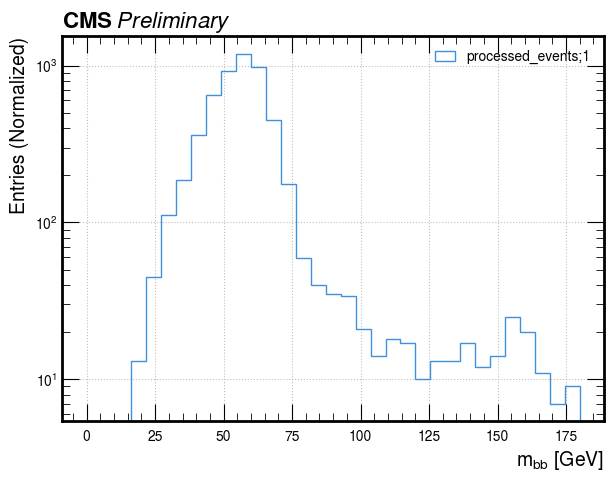

In [37]:
# signal_histogram = get_histogram(
#     file, "NOTAG_merged/srbbgg/dibjet_mass"
# )
#For Signal dibjet_mass
trees = [f["NOTAG_merged/bbgg"] for f in files_t]
dibjet_mass = [tree["dibjet_mass"].array(library="np") for tree in trees]    # NumPy array
diphoton_mass = [tree["diphoton_mass"].array(library="np") for tree in trees]
plt.hist(dibjet_mass[0], bins=33, range=(0,180), histtype="step", label=files_t[0])
plt.grid()
plt.xlabel(r"$m_{bb}$ [GeV]", fontsize=14)
plt.ylabel("Entries (Normalized)", fontsize=14)
plt.yscale("log")
plt.legend()
plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
# plt.xlim(0,180)

plt.show()

# signal_histogram.plot(
#     histtype="step",
#     yerr=True,
#     xerr=True,
#     label="NMSSM_MX300_MY60",
#     color="red",
# )
# plt.legend()
# plt.xlabel("dibjet_mass [GeV]")
# plt.ylabel("Events")
# plt.show()

Background samples

In [9]:
tree = file_bkg["GJetPt40/srbbgg"]
print("Tree keys:", list(tree.keys()))


Tree keys: ['run', 'lumi', 'event', 'puppiMET_pt', 'puppiMET_phi', 'puppiMET_phiJERDown', 'puppiMET_phiJERUp', 'puppiMET_phiJESDown', 'puppiMET_phiJESUp', 'puppiMET_phiUnclusteredDown', 'puppiMET_phiUnclusteredUp', 'puppiMET_ptJERDown', 'puppiMET_ptJERUp', 'puppiMET_ptJESDown', 'puppiMET_ptJESUp', 'puppiMET_ptUnclusteredDown', 'puppiMET_ptUnclusteredUp', 'puppiMET_sumEt', 'lead_pho_pt', 'lead_pho_eta', 'lead_pho_phi', 'sublead_pho_pt', 'sublead_pho_eta', 'sublead_pho_phi', 'lead_bjet_pt', 'lead_bjet_eta', 'lead_bjet_phi', 'sublead_bjet_pt', 'sublead_bjet_eta', 'sublead_bjet_phi', 'dibjet_mass', 'diphoton_mass', 'bbgg_mass', 'dibjet_pt', 'diphoton_pt', 'bbgg_pt', 'bbgg_eta', 'bbgg_phi', 'DeltaPhi_j1MET', 'DeltaPhi_j2MET', 'Res_chi_t0', 'Res_chi_t1', 'lepton1_mvaID', 'lepton1_pt', 'lepton1_pfIsoId', 'n_jets', 'weight_central', 'dibjet_eta', 'dibjet_phi', 'diphoton_eta', 'diphoton_phi', 'lead_bjet_PNetB', 'sublead_bjet_PNetB', 'pholead_PtOverM', 'phosublead_PtOverM', 'FirstJet_PtOverM', '

Background Stack PLots

[21697, 34, 170]


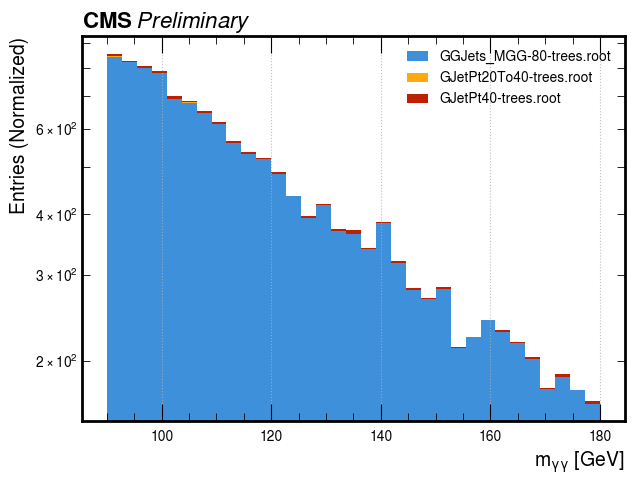

In [15]:
#TREES
#Trees file



# #OVERLAY

# for path, c, lbl in zip(filepaths_bkg_trees, colors, labels):
#     with uproot.open(path) as f:
#         # Find the srbbgg tree
#         tree_key = next(k for k in f.keys() if "srbbgg" in k)
#         tree = f[tree_key]
        
#         # Extract dibjet_mass as NumPy array
#         dibjet_mass = tree["dibjet_mass"].array(library="np")
        
#         # Plot with step histogram
#         plt.hist(dibjet_mass, bins=edges, histtype="step", color=c, label=lbl)

# plt.xlabel("diphoton_mass [GeV]")
# plt.ylabel("Events")
# plt.legend()
# plt.tight_layout()
# plt.show()





#STACKED PLOT for Non-Res BKG
#------------------------------------------------------------------------------------------------------------------------------------------------------

top_dirs = [
    "GGJets_MGG-80",
    "GJetPt20To40",
    "GJetPt40"
]

labels = [fp.split('/')[-1] for fp in filepaths_bkg_trees]
summed = []
# Read all dibjet_mass arrays
diphoton_arrays = []
for fpath, top_dir in zip(filepaths_bkg_trees, top_dirs):
    with uproot.open(fpath) as f:
        tree = f[f"{top_dir}/bbgg"]
        diphoton_arrays.append(tree["diphoton_mass"].array())
print(ak.num(diphoton_arrays))

# plt.figure(figsize=(8,6))
plt.yscale("log")
plt.hist(diphoton_arrays, bins=33, range=(90,180), stacked=True, label=labels)
plt.grid()
plt.xlabel(r"$m_{\gamma\gamma}$ [GeV]", fontsize=14)
plt.ylabel("Entries (Normalized)", fontsize=14)
plt.yscale("log")
plt.legend()
plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
plt.show()
# #------------------------------------------------------------------------------------------------------------------------------------------------------

# #Summed PLOT for Non-Res BKG
# #------------------------------------------------------------------------------------------------------------------------------------------------------
# top_dirs = ["GGJets_MGG-80", "GJetPt20To40", "GJetPt40"]
# labels = [fp.split('/')[-1] for fp in filepaths_bkg_trees]

# # collect numpy arrays (use library="np" to get numpy arrays)
# diphoton_arrays = []
# for fpath, top_dir in zip(filepaths_bkg_trees, top_dirs):
#     with uproot.open(fpath) as f:
#         tree = f[f"{top_dir}/bbgg"]
#         diphoton_arrays.append(tree["diphoton_mass"].array(library="np"))

# # concatenate (sum of events = just concat all events)
# summed = np.concatenate(diphoton_arrays)

# plt.figure(figsize=(8,6))
# plt.hist(summed, bins=33, range=(90,180), histtype='step',label= 'Non-Res Background (Summed)' ,color=color[0], alpha=0.5)
# plt.xlabel("Diphoton Mass [GeV]")
# plt.ylabel("Events")
# plt.legend()
# plt.title("Summed Diphoton Mass (concatenated events)")
# plt.show()



Overlay before and after of cuts for the bkg

[4390, 19, 48] 34.32 4457
[4870, 21, 50] 38.07 4941


[5146, 19, 48] 40.54 5213
[5794, 18, 54] 48.26 5866
[5770, 15, 52] 49.27 5837
[6162, 14, 55] 53.62 6231
[6313, 7, 55] 64.61 6375
[6682, 2, 53] 80.91 6737
[21697, 34, 170]
21901


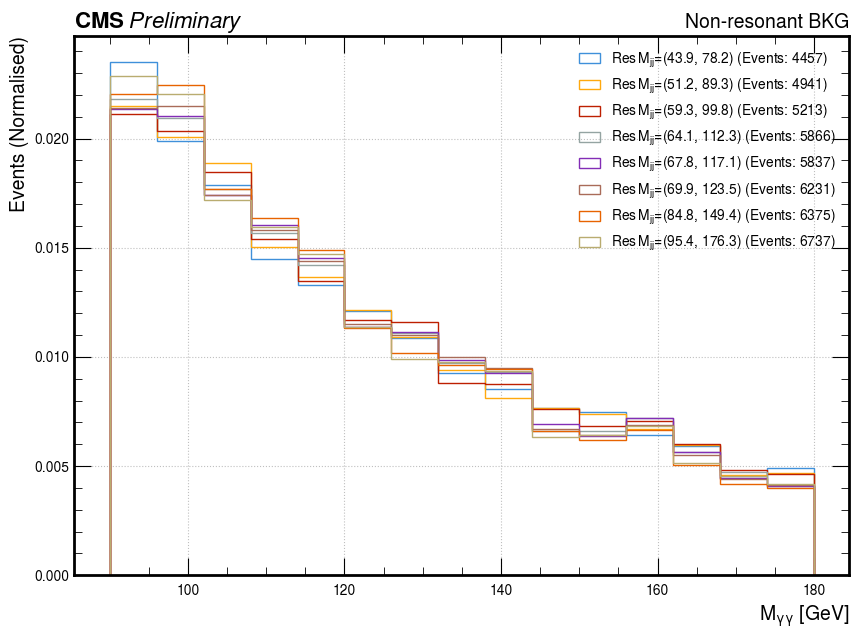

[4625, 18, 51] 35.28 4694
[5381, 23, 60] 41.93 5464
[5223, 19, 49] 42.38 5291
[6127, 20, 57] 52.51 6204
[6066, 19, 59] 53.23 6144
[6222, 17, 59] 56.34 6298
[6450, 7, 51] 69.80 6508
[6736, 2, 53] 88.28 6791
[21697, 34, 170]
21901


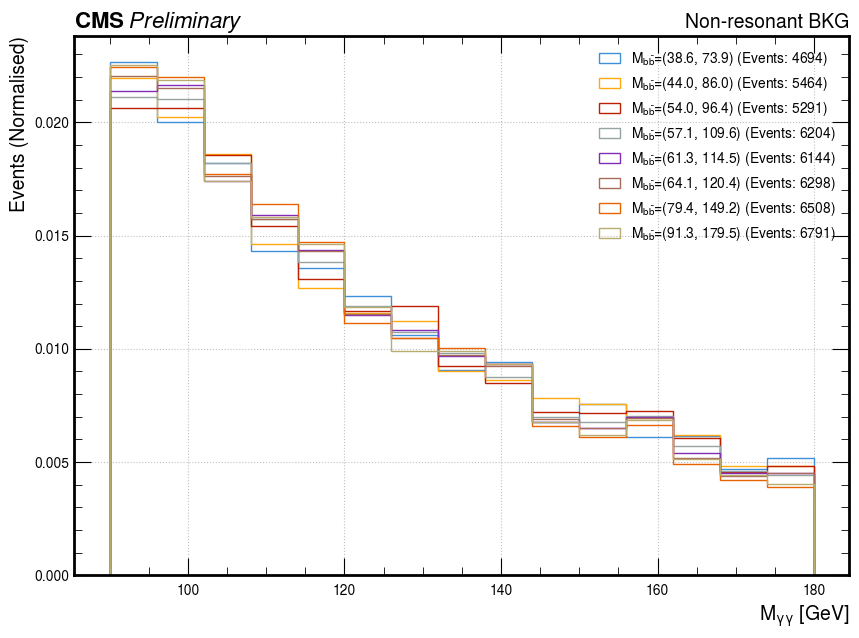

In [ ]:
# #DIBJET MASS CUTS-- STACKED
# diphoton_arrays = []

# for fpath, top_dir in zip(filepaths_bkg_trees, top_dirs):
#     with uproot.open(fpath) as f:
#         tree = f[f"{top_dir}/bbgg"]
#         dibjet_mass = tree["dibjet_mass"].array()
#         # FirstJet_PtOverM = tree["FirstJet_PtOverM"].array()
#         # SecondJet_PtOverM = tree["SecondJet_PtOverM"].array()
#         diphoton_mass = tree["diphoton_mass"].array()
#         # Apply selection: dibjet_mass in [55, 65]
#         mask = (dibjet_mass >= 50) & (dibjet_mass <= 70)
#         # mask = (FirstJet_PtOverM > 0.33) & (SecondJet_PtOverM > 0.25)
#         diphoton_arrays.append(diphoton_mass[mask])
        
# print(ak.num(diphoton_arrays))
# plt.figure(figsize=(8,6))
# plt.hist(diphoton_arrays, bins=33, range=(90,180), stacked=True, label=labels, color={color[0],color[1],color[2]})

# plt.xlabel("Diphoton Mass [GeV]")
# plt.ylabel("Events")
# plt.title("MX=300GeV, MY=60GeV")
# plt.legend()
# plt.show()
#------------------------------------------------------------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------------------------------------------------------------

#MASS CUTS-- Summed
branch_name = ["Res_dijet_mass_DNNreg", "dibjet_mass"]
xlabel = [r"$\mathrm{Res}\,M_{jj}$",r"$M_{b\bar{b}}$"]
top_dirs = [
    "GGJets_MGG-80",
    "GJetPt20To40",
    "GJetPt40"
]
# dibjet_cuts=[(50,70), (60,80), (70,90), (80,100), (85,105)]

# branch="dibjet_mass"
for branch, dist in zip(branch_name, xlabel):
    line_handles = []  # to store custom line handles for legend
    line_labels = []
    plt.figure(figsize=(10,7))
    for fpath in filepaths_trees:
        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        diphoton_arrays = []
        diphoton_arrays_unmasked = []
        summed_cut= []
        for path, top_dir in zip(filepaths_bkg_trees, top_dirs):
            with uproot.open(path) as f:
                tree = f[f"{top_dir}/bbgg"]
                mask_var = tree[branch].array()
                # dibjet_mass = tree["dibjet_mass"].array()
                # Res_dijet_mass_DNNreg = tree["Res_dijet_mass_DNNreg"].array()
                # FirstJet_PtOverM = tree["FirstJet_PtOverM"].array()
                # SecondJet_PtOverM = tree["SecondJet_PtOverM"].array()
                diphoton_mass = tree["diphoton_mass"].array()
                # diphoton_mass = tree["dibjet_mass"].array()
                # Apply selection: dibjet_mass in [55, 65]
                
                mask = (mask_var >= (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])) & (mask_var <= (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0]))
                # mask = (FirstJet_PtOverM > 0.33) & (SecondJet_PtOverM > 0.25)
                diphoton_arrays_unmasked.append(diphoton_mass)
                diphoton_arrays.append(diphoton_mass[mask])
        summed_cut = np.concatenate(diphoton_arrays)        
        
        
        ul = (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        ll = (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        print(ak.num(diphoton_arrays), f"{(ul-ll):.2f}", ak.count(summed_cut))
        n,bins, patches = plt.hist(summed_cut, bins=15, range=(90,180), histtype='step', label= rf"{dist}=({ll:.1f}, {ul:.1f}) (Events: {ak.count(summed_cut)})" )
        # plt.hist(summed_cut, bins=55, range=(100,500), histtype='step', label= f"{ll:.1f}<{dist}<{ul:.1f}" )
        # for p in patches:
        #     p.set_linestyle('-')
        #     line_handles.append(p)
        #     line_labels.append(f"{dist}: ({ll:.1f}, {ul:.1f})")

        plt.xlabel(r"$M_{\gamma\gamma}$ [GeV]", fontsize=14)
        plt.ylabel("Events (Normalised)", fontsize=14)
        # plt.yscale("log")
        plt.legend()
        plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
        plt.title("Non-resonant BKG", loc='right', fontsize=14)
        # plt.title(f"{branch}-2 sigma cuts", loc='right', fontsize=14)
    print(ak.num(diphoton_arrays_unmasked)) 
    print(ak.count(diphoton_arrays_unmasked))   
    plt.hist(np.concatenate(diphoton_arrays_unmasked), bins=20, range=(90,180), histtype='step', label= f"No Cut (Events: {ak.count(diphoton_arrays_unmasked)})")
    # plt.yscale("log")
    
    plt.legend()
    plt.grid()

    # plt.legend()
    plt.show()
#------------------------------------------------------------------------------------------------------------------------------------------------------



Additional Total invariant mass cuts

[569, 1, 2] 34.32 572
[680, 3, 4] 38.07 687
[640, 3, 5] 40.54 648
[918, 3, 8] 48.26 929
[926, 3, 10] 49.27 939
[1058, 2, 13] 53.62 1073
[1181, 1, 14] 64.61 1196
[1534, 1, 11] 80.91 1546
[21697, 34, 170]
21901


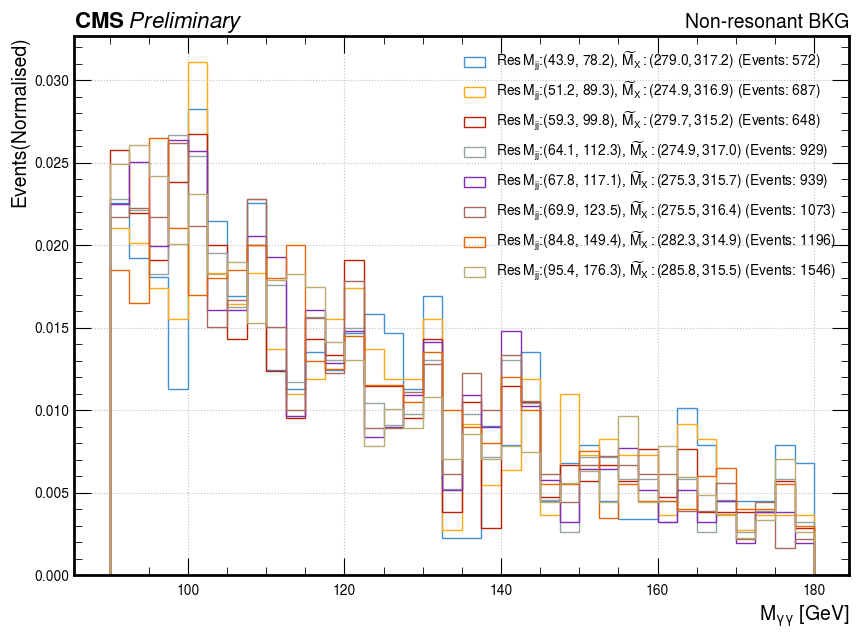

[582, 1, 2] 35.28 585
[744, 4, 5] 41.93 753
[635, 3, 5] 42.38 643
[960, 4, 10] 52.51 974
[982, 4, 14] 53.23 1000
[1063, 3, 13] 56.34 1079
[1217, 1, 11] 69.80 1229
[1577, 1, 12] 88.28 1590
[21697, 34, 170]
21901


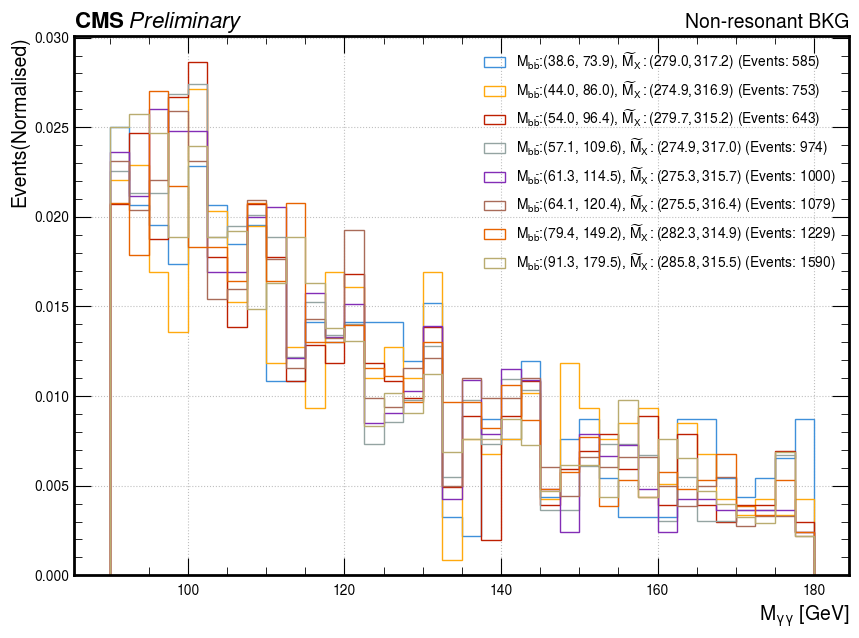

In [29]:
#MASS CUTS-- Summed
branch_name = ["Res_dijet_mass_DNNreg", "dibjet_mass"]
xlabel = [r"$\mathrm{Res}\,M_{jj}$",r"$M_{b\bar{b}}$"]
top_dirs = [
    "GGJets_MGG-80",
    "GJetPt20To40",
    "GJetPt40"
]
# dibjet_cuts=[(50,70), (60,80), (70,90), (80,100), (85,105)]

# branch="dibjet_mass"
for branch, dist in zip(branch_name, xlabel):
    line_handles = []  # to store custom line handles for legend
    line_labels = []
    plt.figure(figsize=(10,7))
    for fpath in filepaths_trees:
        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        diphoton_arrays = []
        diphoton_arrays_unmasked = []
        summed_cut= []
        for path, top_dir in zip(filepaths_bkg_trees, top_dirs):
            with uproot.open(path) as f:
                tree = f[f"{top_dir}/bbgg"]
                bbgg_mass = tree["bbgg_mass"].array(library="np")
                diphoton_mass = tree["diphoton_mass"].array(library="np")
                dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
                M_X = bbgg_mass - (diphoton_mass - 125.25) - (dijet_mass - Y_Mass)
                mask_var1 = tree[branch].array()
                mask_var2 = M_X
                # dibjet_mass = tree["dibjet_mass"].array()
                # Res_dijet_mass_DNNreg = tree["Res_dijet_mass_DNNreg"].array()
                # FirstJet_PtOverM = tree["FirstJet_PtOverM"].array()
                # SecondJet_PtOverM = tree["SecondJet_PtOverM"].array()
                # diphoton_mass = tree["diphoton_mass"].array()
                # diphoton_mass = tree["dibjet_mass"].array()
                # Apply selection: dibjet_mass in [55, 65]
                
                mask1 = (mask_var1 >= (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])) & (mask_var1 <= (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0]))
                mask2 = (mask_var2 >= (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]-2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])) & (mask_var2 <= (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]+2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0]))
                mask = mask1 & mask2 #To apply mass cuts on both dijet and MX
                # mask = mask2 # To apply mass cuts only on MX
                # mask = (FirstJet_PtOverM > 0.33) & (SecondJet_PtOverM > 0.25)
                diphoton_arrays_unmasked.append(diphoton_mass)
                diphoton_arrays.append(diphoton_mass[mask])
        summed_cut = np.concatenate(diphoton_arrays)        
        
        # plt.figure(figsize=(8,6))
        ul = (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        ll = (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        ul1 = (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]+2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])
        ll1 = (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]-2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])
        print(ak.num(diphoton_arrays), f"{(ul-ll):.2f}", ak.count(summed_cut))
        #To apply mass cuts on both dijet and MX
        n,bins, patches = plt.hist(summed_cut, bins=36, range=(90,180), histtype='step', density = True, label= rf"{dist}:({ll:.1f}, {ul:.1f}), $\widetilde{{M}}_X:({ll1:.1f}, {ul1:.1f})$ (Events: {ak.count(diphoton_arrays)})" )
        # To apply mass cuts only on MX
        # n,bins, patches = plt.hist(summed_cut, bins=36, range=(90,180), histtype='step', density = True, label= rf"$\widetilde{{M}}_X:({ll1:.1f}, {ul1:.1f})$ (Events: {ak.count(diphoton_arrays)})" )
        # plt.hist(summed_cut, bins=55, range=(100,500), histtype='step', label= f"{ll:.1f}<{dist}<{ul:.1f}" )
        # for p in patches:
        #     p.set_linestyle('-')
        #     line_handles.append(p)
        #     line_labels.append(f"{dist}: ({ll:.1f}, {ul:.1f})")

        plt.xlabel(r"$M_{\gamma\gamma}$ [GeV]", fontsize=14)
        plt.ylabel("Events(Normalised)", fontsize=14)
        # plt.yscale("log")
        plt.legend()
        plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
        
        plt.title("Non-resonant BKG", loc='right', fontsize=14)
        
        # plt.title(f"{branch}-2 sigma cuts", loc='right', fontsize=14)
    print(ak.num(diphoton_arrays_unmasked)) 
    print(ak.count(diphoton_arrays_unmasked))   
    # plt.hist(np.concatenate(diphoton_arrays_unmasked), bins=36, range=(90,180), histtype='step', label= f"No Cut (Events: {ak.count(diphoton_arrays_unmasked)})")
    # plt.yscale("log")
    plt.legend()
    plt.grid()
    # plt.legend()
    plt.show()
#------------------------------------------------------------------------------------------------------------------------------------------------------

In [51]:
for i, sub in enumerate(diphoton_arrays_unmasked):
    print(f"Sublist {i} has {len(sub)} entries")
    print(sub[:5])   # print first 5 elements of that sublist


Sublist 0 has 21697 entries
[105, 217, 124, 174, 188]
Sublist 1 has 34 entries
[104, 100, 99, 80.1, 84.9]
Sublist 2 has 170 entries
[202, 78.6, 124, 102, 90.2]


Comparision between Res_dijet_mass_DNNreg and dibjet_mass cuts

[4388, 19, 48] 34.30 4455
[4625, 18, 51] 35.28 4694
M_Y =60.0
[21697, 34, 170]
21901


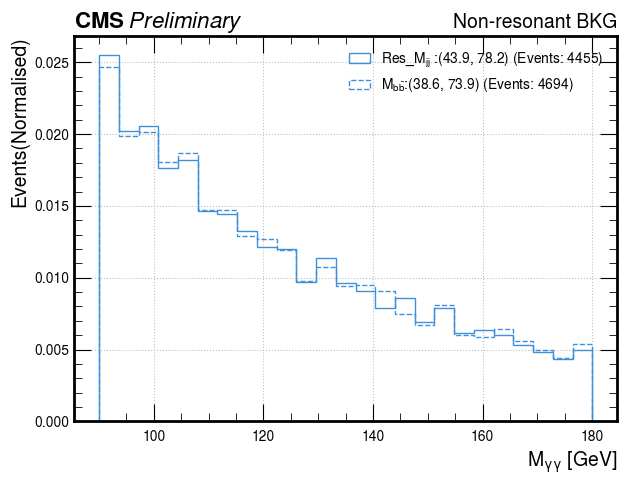

[4870, 21, 50] 38.07 4941
[5381, 23, 60] 41.93 5464
M_Y =70.0
[21697, 34, 170]
21901


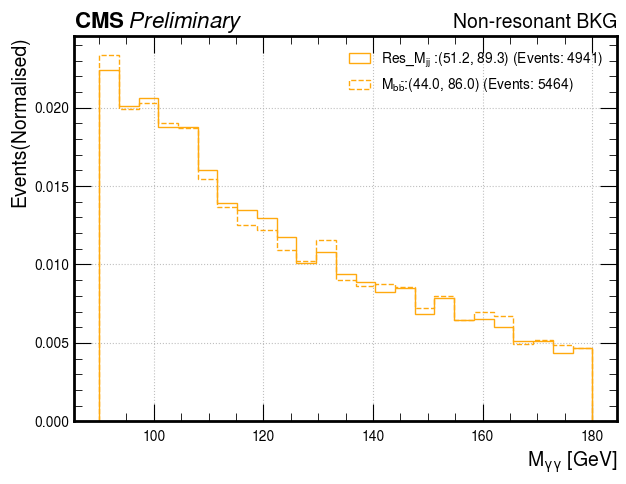

[5146, 19, 48] 40.54 5213
[5223, 19, 49] 42.38 5291
M_Y =80.0
[21697, 34, 170]
21901


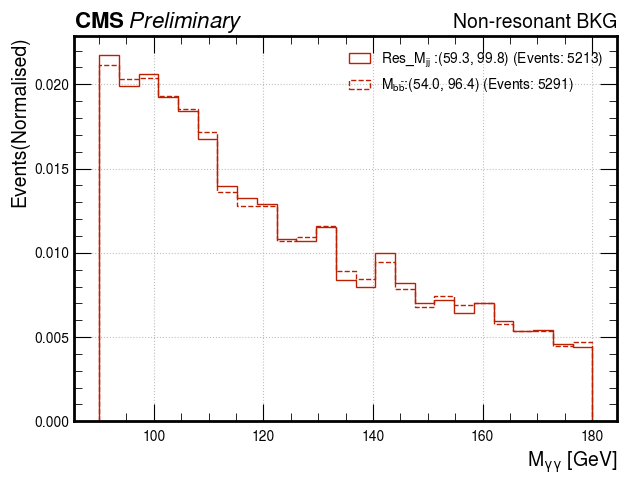

[5794, 18, 54] 48.26 5866
[6127, 20, 57] 52.51 6204
M_Y =90.0
[21697, 34, 170]
21901


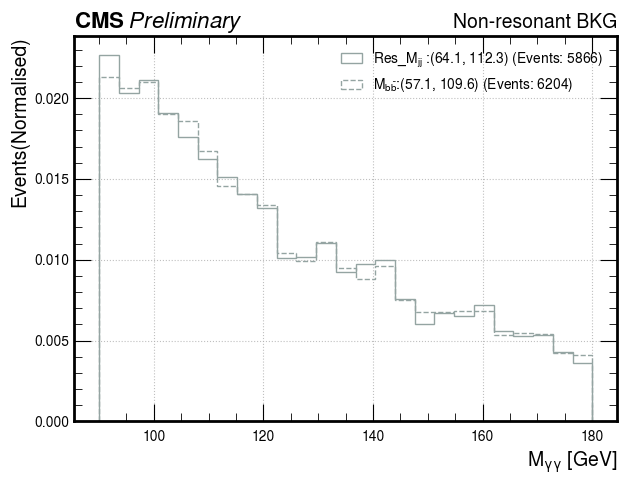

[5770, 15, 52] 49.27 5837
[6066, 19, 59] 53.23 6144
M_Y =95.0
[21697, 34, 170]
21901


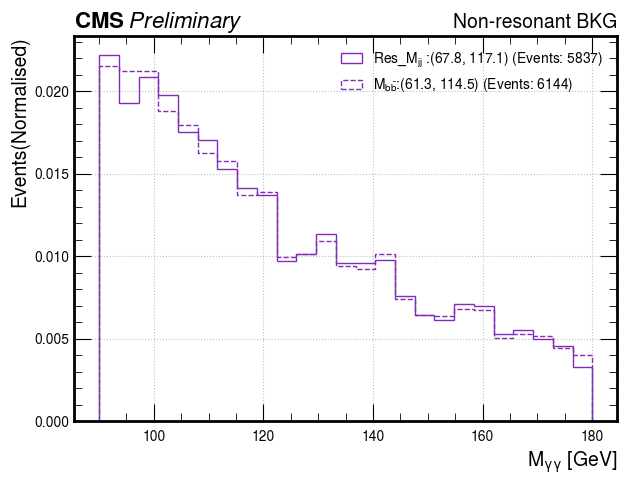

[6162, 14, 55] 53.62 6231
[6222, 17, 59] 56.34 6298
M_Y =100.0
[21697, 34, 170]
21901


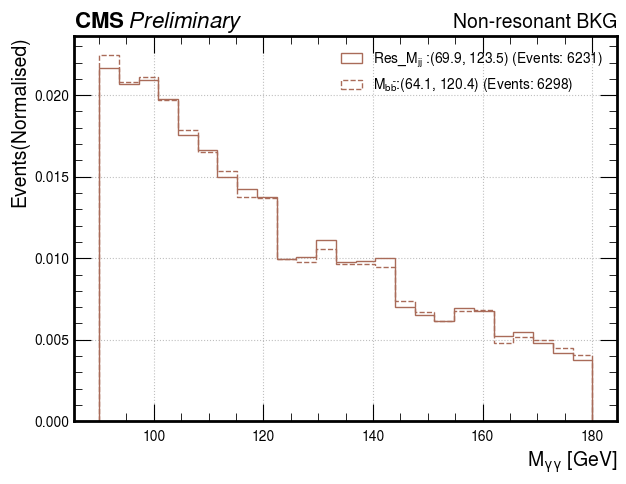

[6313, 7, 55] 64.61 6375
[6450, 7, 51] 69.80 6508
M_Y =125.0
[21697, 34, 170]
21901


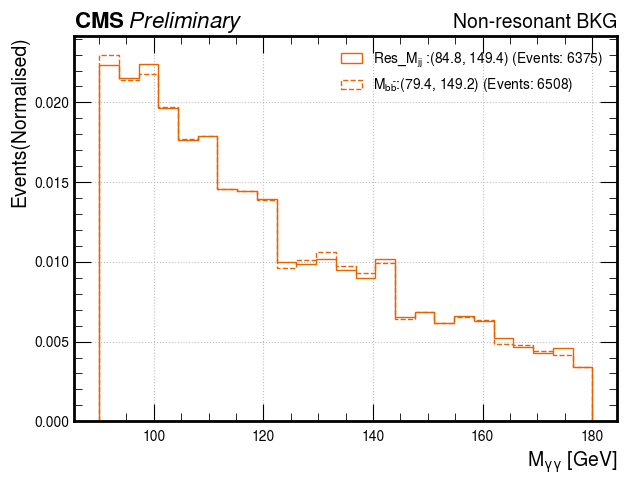

[6682, 2, 53] 80.91 6737
[6736, 2, 53] 88.28 6791
M_Y =150.0
[21697, 34, 170]
21901


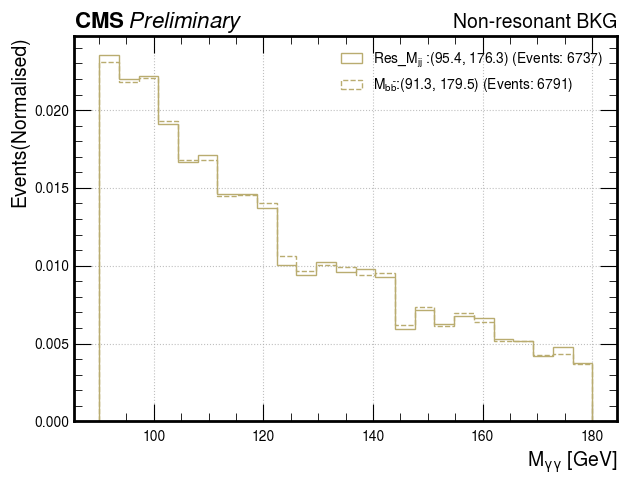

In [14]:
#------------------------------------------------------------------------------------------------------------------------------------------------------

#MASS CUTS-- Summed
color=[
        "#3f90da",
        "#ffa90e",
        "#bd1f01",
        "#94a4a2",
        "#832db6",
        "#a96b59",
        "#e76300",
        "#b9ac70",
        "#717581",
        "#92dadd",
    ]
branch_name = ["Res_dijet_mass_DNNreg", "dibjet_mass"]
xlabel = [r"Res_$M_{jj}$ ",r"$M_{b\bar{b}}$"]
top_dirs = [
    "GGJets_MGG-80",
    "GJetPt20To40",
    "GJetPt40"
]
# dibjet_cuts=[(50,70), (60,80), (70,90), (80,100), (85,105)]

# branch="dibjet_mass"
for fpath,c in zip(filepaths_trees, color):
    line_handles = []  # to store custom line handles for legend
    line_labels = []
    for branch, dist in zip(branch_name, xlabel):
        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        diphoton_arrays = []
        diphoton_arrays_unmasked = []
        summed_cut= []
        for path, top_dir in zip(filepaths_bkg_trees, top_dirs):
            with uproot.open(path) as f:
                tree = f[f"{top_dir}/bbgg"]
                mask_var = tree[branch].array()
                # dibjet_mass = tree["dibjet_mass"].array()
                # Res_dijet_mass_DNNreg = tree["Res_dijet_mass_DNNreg"].array()
                # FirstJet_PtOverM = tree["FirstJet_PtOverM"].array()
                # SecondJet_PtOverM = tree["SecondJet_PtOverM"].array()
                diphoton_mass = tree["diphoton_mass"].array()
                # diphoton_mass = tree["dibjet_mass"].array()
                # Apply selection: dibjet_mass in [55, 65]
                
                mask = (mask_var >= (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])) & (mask_var <= (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0]))
                # mask = (FirstJet_PtOverM > 0.33) & (SecondJet_PtOverM > 0.25)
                diphoton_arrays_unmasked.append(diphoton_mass)
                diphoton_arrays.append(diphoton_mass[mask])
        summed_cut = np.concatenate(diphoton_arrays)        
        
        # plt.figure(figsize=(8,6))
        ul = (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        ll = (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        print(ak.num(diphoton_arrays), f"{(ul-ll):.2f}", ak.count(summed_cut))
        
        n,bins, patches = plt.hist(summed_cut, bins=25, range=(90,180), histtype='step', density=True,label= f"{dist}:({ll:.1f}, {ul:.1f}) (Events: {ak.count(diphoton_arrays)})", color = c )
        # plt.hist(summed_cut, bins=55, range=(100,500), histtype='step', label= f"{ll:.1f}<{dist}<{ul:.1f}" )
    styles = ['--', '-']
    print(f"M_Y ={Y_Mass}")
    for p, s in zip(patches, styles):
        p.set_linestyle(s)
        line_handles.append(p)
        line_labels.append(f"{dist}: ({ll:.1f}, {ul:.1f}), (Events: {ak.count(diphoton_arrays)})")

    plt.xlabel(r"$M_{\gamma\gamma}$ [GeV]", fontsize=14)
    plt.ylabel("Events(Normalised)", fontsize=14)
    # plt.yscale("log")
    plt.legend()
    plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
    plt.title("Non-resonant BKG", loc='right', fontsize=14)
    # plt.title(f"{branch}-2 sigma cuts", loc='right', fontsize=14)
    print(ak.num(diphoton_arrays_unmasked)) 
    print(ak.count(diphoton_arrays_unmasked))   
    # plt.hist(np.concatenate(diphoton_arrays_unmasked), bins=55, range=(90,180), histtype='step', label= f"No Cut (Events: {ak.count(diphoton_arrays_unmasked)})", color="#717581")
    # plt.yscale("log")
    plt.legend()
    plt.grid()
    # plt.legend()
    plt.show()
#------------------------------------------------------------------------------------------------------------------------------------------------------


Comparision between Res_dijet_mass_DNNreg and dibjet_mass cuts Along with Reduced INvariant mass cuts

M_Y =60.0
[21697, 34, 170]
21901


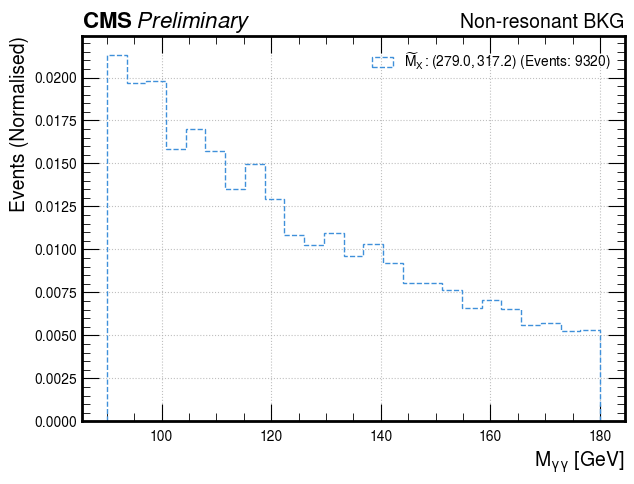

M_Y =70.0
[21697, 34, 170]
21901


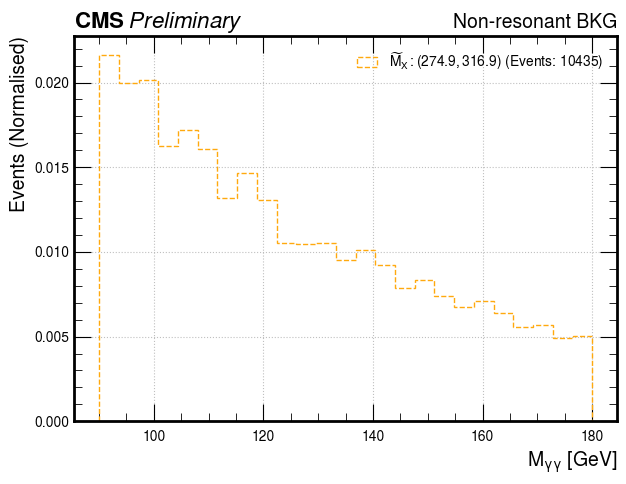

M_Y =80.0
[21697, 34, 170]
21901


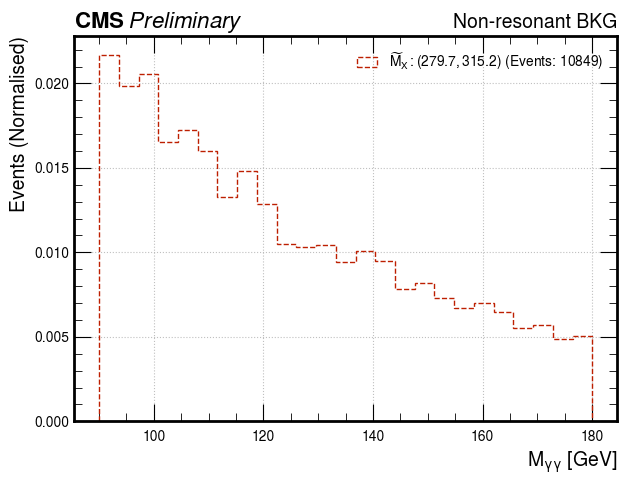

M_Y =90.0
[21697, 34, 170]
21901


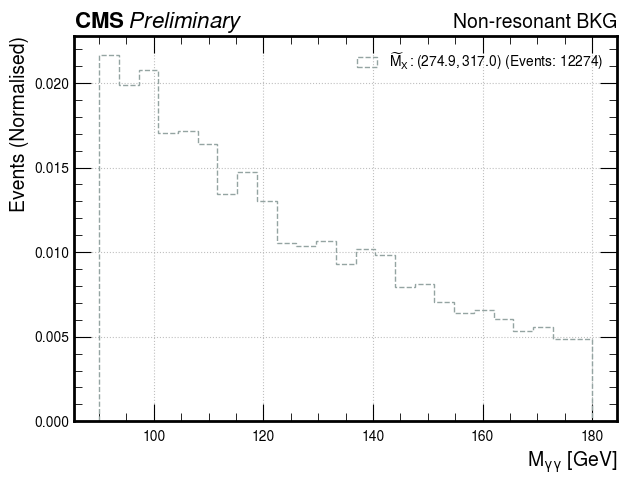

M_Y =95.0
[21697, 34, 170]
21901


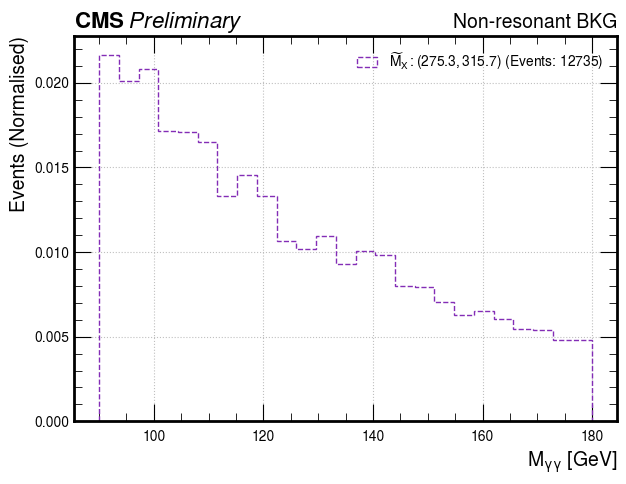

M_Y =100.0
[21697, 34, 170]
21901


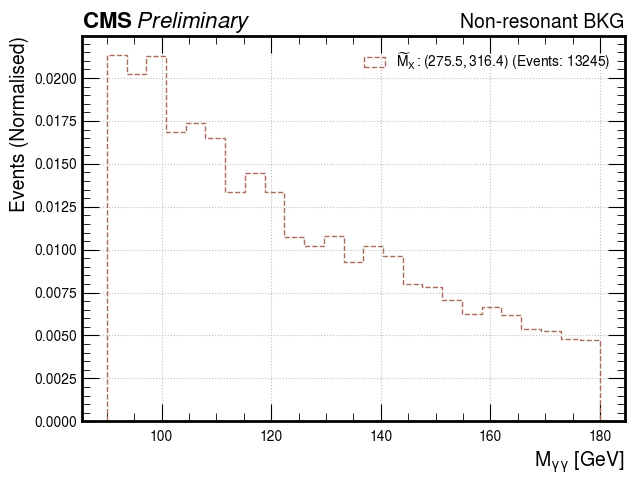

M_Y =125.0
[21697, 34, 170]
21901


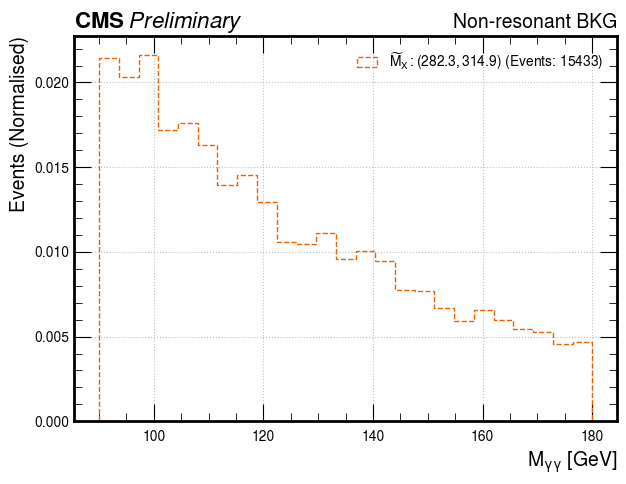

M_Y =150.0
[21697, 34, 170]
21901


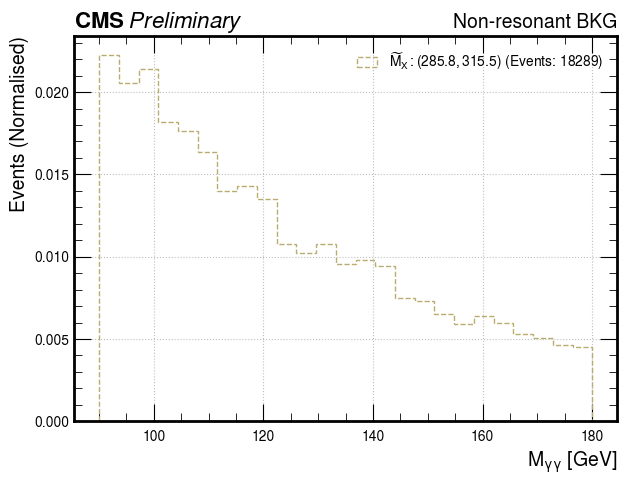

In [13]:
#------------------------------------------------------------------------------------------------------------------------------------------------------

#MASS CUTS-- Summed
color=[
        "#3f90da",
        "#ffa90e",
        "#bd1f01",
        "#94a4a2",
        "#832db6",
        "#a96b59",
        "#e76300",
        "#b9ac70",
        "#717581",
        "#92dadd",
    ]
branch_name = ["Res_dijet_mass_DNNreg", "dibjet_mass"]
xlabel = [r"Res_$M_{jj}$ ",r"$M_{b\bar{b}}$"]
top_dirs = [
    "GGJets_MGG-80",
    "GJetPt20To40",
    "GJetPt40"
]
# dibjet_cuts=[(50,70), (60,80), (70,90), (80,100), (85,105)]

# branch="dibjet_mass"
for fpath,c in zip(filepaths_trees, color):
    
    line_handles = []  # to store custom line handles for legend
    line_labels = []
    for branch, dist in zip(branch_name, xlabel):
        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        diphoton_arrays = []
        diphoton_arrays_unmasked = []
        summed_cut= []
        for path, top_dir in zip(filepaths_bkg_trees, top_dirs):
            with uproot.open(path) as f:
                tree = f[f"{top_dir}/bbgg"]
                bbgg_mass = tree["bbgg_mass"].array(library="np")
                diphoton_mass = tree["diphoton_mass"].array(library="np")
                dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
                M_X = bbgg_mass - (diphoton_mass - 125.25) - (dijet_mass - Y_Mass)
                mask_var1 = tree[branch].array()
                mask_var2 = M_X
                # dibjet_mass = tree["dibjet_mass"].array()
                # Res_dijet_mass_DNNreg = tree["Res_dijet_mass_DNNreg"].array()
                # FirstJet_PtOverM = tree["FirstJet_PtOverM"].array()
                # SecondJet_PtOverM = tree["SecondJet_PtOverM"].array()
                diphoton_mass = tree["diphoton_mass"].array()
                # diphoton_mass = tree["dibjet_mass"].array()
                # Apply selection: dibjet_mass in [55, 65]
                
                mask1 = (mask_var1 >= (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])) & (mask_var1 <= (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0]))
                mask2 = (mask_var2 >= (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]-2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])) & (mask_var1 <= (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]+2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0]))
                mask = mask1 & mask2
                diphoton_arrays_unmasked.append(diphoton_mass)
                diphoton_arrays.append(diphoton_mass[mask])
        summed_cut = np.concatenate(diphoton_arrays)        
        
        # plt.figure(figsize=(8,6))
        ul = (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        ll = (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        ul1 = (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]+2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])
        ll1 = (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]-2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])
        print(ak.num(diphoton_arrays), f"{(ul-ll):.2f}", ak.count(summed_cut))
        n,bins, patches = plt.hist(summed_cut, bins=25, range=(90,180), histtype='step',density=True, label= rf"{dist}:({ll:.1f}, {ul:.1f}), $\widetilde{{M}}_X:({ll1:.1f}, {ul1:.1f})$ (Events: {ak.count(diphoton_arrays)})", color = c )
        # plt.hist(summed_cut, bins=55, range=(100,500), histtype='step', label= f"{ll:.1f}<{dist}<{ul:.1f}" )
    print(f"M_Y ={Y_Mass}")
    styles = ['--', '-']
    for p, s in zip(patches, styles):
        p.set_linestyle(s)
        line_handles.append(p)
        line_labels.append(f"{dist}: ({ll:.1f}, {ul:.1f}), (Events: {ak.count(diphoton_arrays)})")
    
    plt.xlabel(r"$M_{\gamma\gamma}$ [GeV]", fontsize=14)
    plt.ylabel("Events (Normalised)", fontsize=14)
    # plt.yscale("log")
    plt.legend()
    plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
    plt.title("Non-resonant BKG", loc='right', fontsize=14)
    # plt.title(f"{branch}-2 sigma cuts", loc='right', fontsize=14)
    print(ak.num(diphoton_arrays_unmasked)) 
    print(ak.count(diphoton_arrays_unmasked))   
    # plt.hist(np.concatenate(diphoton_arrays_unmasked), bins=55, range=(90,180), histtype='step', label= f"No Cut (Events: {ak.count(diphoton_arrays_unmasked)})", color="#717581")
    # plt.yscale("log")
    plt.legend()
    plt.grid()
    # plt.legend()
    plt.show()

2 SIGMA CUTS APPLIED ON SIGNAL to check how much signal is kept

[3825] 34.30 3825
[3895] 38.07 3895
[3749] 40.54 3749
[4244] 48.26 4244
[4273] 49.27 4273
[4570] 53.62 4570
[5343] 64.61 5343
[6248] 80.91 6248
[8092]
8092


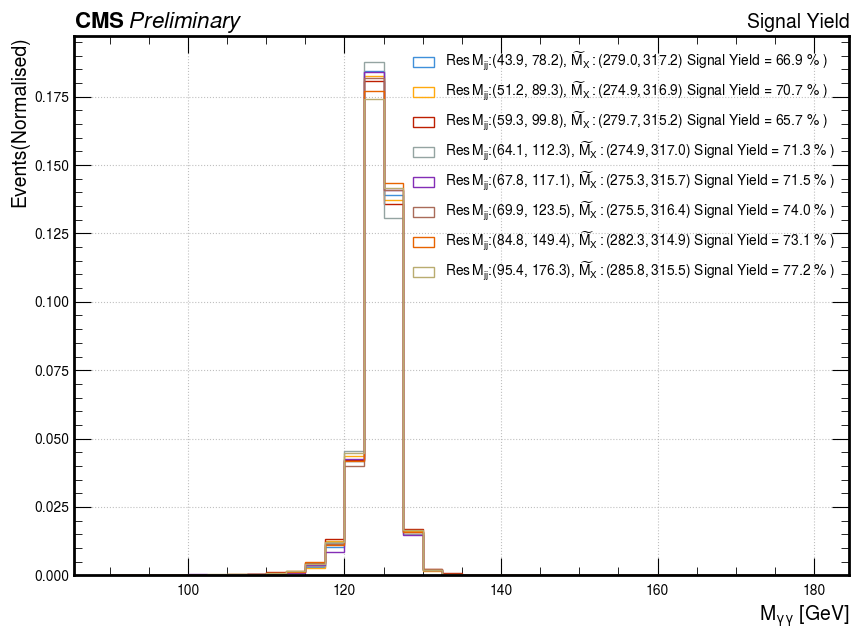

[3887] 35.28 3887
[4004] 41.93 4004
[3814] 42.38 3814
[4327] 52.51 4327
[4340] 53.23 4340
[4586] 56.34 4586
[5378] 69.80 5378
[6261] 88.28 6261
[8092]
8092


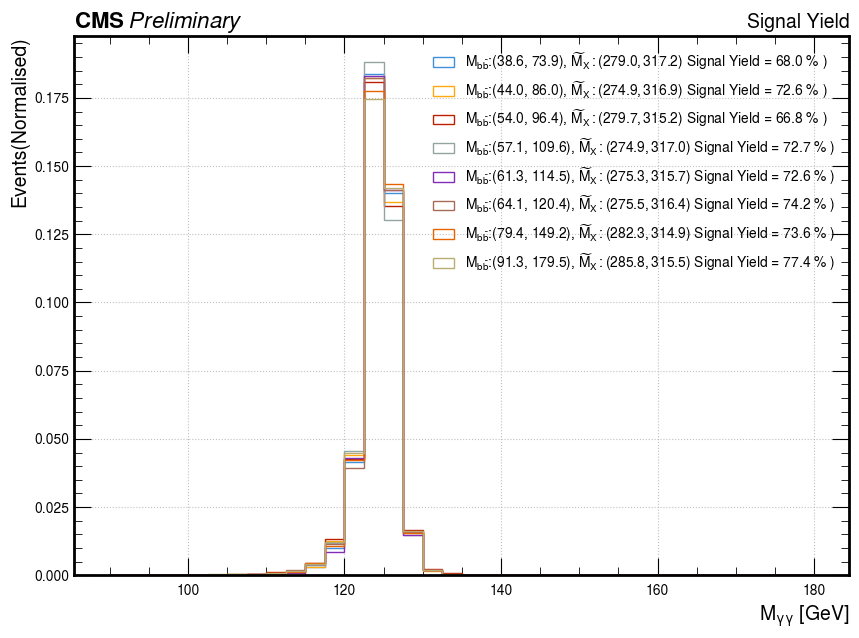

In [18]:
#MASS CUTS-- Summed
branch_name = ["Res_dijet_mass_DNNreg", "dibjet_mass"]
xlabel = [r"$\mathrm{Res}\,M_{jj}$",r"$M_{b\bar{b}}$"]
top_dirs = [
    "GGJets_MGG-80",
    "GJetPt20To40",
    "GJetPt40"
]
# dibjet_cuts=[(50,70), (60,80), (70,90), (80,100), (85,105)]

# branch="dibjet_mass"
for branch, dist in zip(branch_name, xlabel):
    line_handles = []  # to store custom line handles for legend
    line_labels = []
    plt.figure(figsize=(10,7))
    for fpath in filepaths_trees:
        yield_signal = 0
        sample_name = os.path.basename(fpath).replace("-trees.root", "")
        Y_Mass=float(sample_name.replace("NMSSM_MX-300_MY-","" ))
        diphoton_arrays = []
        diphoton_arrays_unmasked = []
        summed_cut= []
        with uproot.open(fpath) as f:
            tree = f[f"NOTAG_merged/bbgg"]
            bbgg_mass = tree["bbgg_mass"].array(library="np")
            diphoton_mass = tree["diphoton_mass"].array(library="np")
            dijet_mass = tree["Res_dijet_mass_DNNreg"].array(library="np")
            M_X = bbgg_mass - (diphoton_mass - 125.25) - (dijet_mass - Y_Mass)
            mask_var1 = tree[branch].array()
            mask_var2 = M_X
            # dibjet_mass = tree["dibjet_mass"].array()
            # Res_dijet_mass_DNNreg = tree["Res_dijet_mass_DNNreg"].array()
            # FirstJet_PtOverM = tree["FirstJet_PtOverM"].array()
            # SecondJet_PtOverM = tree["SecondJet_PtOverM"].array()
            # diphoton_mass = tree["diphoton_mass"].array()
            # diphoton_mass = tree["dibjet_mass"].array()
            # Apply selection: dibjet_mass in [55, 65]
            
            mask1 = (mask_var1 >= (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])) & (mask_var1 <= (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0]))
            mask2 = (mask_var2 >= (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]-2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])) & (mask_var2 <= (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]+2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0]))
            mask = mask1 & mask2 #To apply mass cuts on both dijet and MX
            # mask = mask2 # To apply mass cuts only on MX
            # mask = (FirstJet_PtOverM > 0.33) & (SecondJet_PtOverM > 0.25)
            diphoton_arrays_unmasked.append(diphoton_mass)
            diphoton_arrays.append(diphoton_mass[mask])
        summed_cut = np.concatenate(diphoton_arrays)        
        yield_signal = 100*ak.count(diphoton_arrays)/ak.count(diphoton_arrays_unmasked)
        # plt.figure(figsize=(8,6))
        ul = (fit_results[branch][f"{sample_name}"]['mean'][0]+2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        ll = (fit_results[branch][f"{sample_name}"]['mean'][0]-2*fit_results[branch][f"{sample_name}"]['sigma'][0])
        ul1 = (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]+2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])
        ll1 = (fit_results_1["M_X"][f"{sample_name}"]['mean'][0]-2*fit_results_1["M_X"][f"{sample_name}"]['sigma'][0])
        print(ak.num(diphoton_arrays), f"{(ul-ll):.2f}", ak.count(summed_cut))
        #To apply mass cuts on both dijet and MX
        n,bins, patches = plt.hist(summed_cut, bins=36, range=(90,180), histtype='step', density = True, label= rf"{dist}:({ll:.1f}, {ul:.1f}), $\widetilde{{M}}_X:({ll1:.1f}, {ul1:.1f})$ Signal Yield = {yield_signal:.1f} % )" )#(Events: {ak.count(diphoton_arrays)})" )
        # To apply mass cuts only on MX
        # n,bins, patches = plt.hist(summed_cut, bins=36, range=(90,180), histtype='step', density = True, label= rf"$\widetilde{{M}}_X:({ll1:.1f}, {ul1:.1f})$,$M_Y:{Y_Mass}$  Signal Yield = {yield_signal:.1f} % )" )# (Events: Post-cut={ak.count(diphoton_arrays)}, Pre-cut={ak.count(diphoton_arrays_unmasked)}, )" )
        # plt.hist(summed_cut, bins=55, range=(100,500), histtype='step', label= f"{ll:.1f}<{dist}<{ul:.1f}" )
        # for p in patches:
        #     p.set_linestyle('-')
        #     line_handles.append(p)
        #     line_labels.append(f"{dist}: ({ll:.1f}, {ul:.1f})")

        plt.xlabel(r"$M_{\gamma\gamma}$ [GeV]", fontsize=14)
        plt.ylabel("Events(Normalised)", fontsize=14)
        # plt.yscale("log")
        plt.legend()
        plt.title(r"$\bf{CMS} \hspace{0.3} \mathit{Preliminary}$", loc='left', fontsize=16)
        
        plt.title(f"Signal Yield", loc='right', fontsize=14)
        
        # plt.title(f"{branch}-2 sigma cuts", loc='right', fontsize=14)
    print(ak.num(diphoton_arrays_unmasked)) 
    print(ak.count(diphoton_arrays_unmasked))   
    # plt.hist(np.concatenate(diphoton_arrays_unmasked), bins=36, range=(90,180), histtype='step', density = True, label= f"No Cut (Events: {ak.count(diphoton_arrays_unmasked)})")
    # plt.yscale("log")
    plt.legend()
    plt.grid()
    # plt.legend()
    plt.show()
#------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
print(fit_results)

{'Res_dijet_mass_DNNreg': {'NMSSM_MX-300_MY-60': {'mean': (61.1315849961292, 0.0028538531995820904), 'sigma': (23.455185602629786, 0.0), 'alphaL': (1.259218232010277, 0.01569300553966657), 'nL': (141.92163244331368, 0.013324572672274826), 'alphaR': (-2.2134386416449203, 0.000490644304169674), 'nR': (0.5714563088769481, 0.0006041941685308583)}, 'NMSSM_MX-300_MY-70': {'mean': (70.27861376369586, 0.1782424585082154), 'sigma': (22.980755743917236, 0.0), 'alphaL': (1.149860118026452, 0.04407621553874641), 'nL': (142.62811072063798, 0.21018067318523492), 'alphaR': (-1.897931234008139, 0.0644427715271334), 'nR': (0.9361888241283256, 0.10278386253304744)}, 'NMSSM_MX-300_MY-80': {'mean': (79.57880064140231, 0.201949318715144), 'sigma': (22.27244747905705, 0.0), 'alphaL': (0.990943448593709, 0.03847809026612753), 'nL': (138.35246630414386, 191.29904047077645), 'alphaR': (-1.8482266648192773, 0.07727213935466093), 'nR': (1.076162954111375, 0.1420892107615856)}, 'NMSSM_MX-300_MY-90': {'mean': (88.

In [135]:
fpath = "outputfiles/GJetPt20To40-trees.root"

with uproot.open(fpath) as f:
    srbbgg = f["GJetPt20To40/srbbgg"]
    print("Keys inside GJetPt20To40/srbbgg:")
    print(srbbgg.keys())
    print("Type of 'dibjet':", type(srbbgg["dibjet"]))

Keys inside GJetPt20To40/srbbgg:
['run', 'lumi', 'event', 'puppiMET_pt', 'puppiMET_phi', 'puppiMET_phiJERDown', 'puppiMET_phiJERUp', 'puppiMET_phiJESDown', 'puppiMET_phiJESUp', 'puppiMET_phiUnclusteredDown', 'puppiMET_phiUnclusteredUp', 'puppiMET_ptJERDown', 'puppiMET_ptJERUp', 'puppiMET_ptJESDown', 'puppiMET_ptJESUp', 'puppiMET_ptUnclusteredDown', 'puppiMET_ptUnclusteredUp', 'puppiMET_sumEt', 'lead_pho_pt', 'lead_pho_eta', 'lead_pho_phi', 'sublead_pho_pt', 'sublead_pho_eta', 'sublead_pho_phi', 'lead_bjet_pt', 'lead_bjet_eta', 'lead_bjet_phi', 'sublead_bjet_pt', 'sublead_bjet_eta', 'sublead_bjet_phi', 'dibjet_mass', 'diphoton_mass', 'bbgg_mass', 'dibjet_pt', 'diphoton_pt', 'bbgg_pt', 'bbgg_eta', 'bbgg_phi', 'DeltaPhi_j1MET', 'DeltaPhi_j2MET', 'Res_chi_t0', 'Res_chi_t1', 'lepton1_mvaID', 'lepton1_pt', 'lepton1_pfIsoId', 'n_jets', 'weight_central', 'dibjet_eta', 'dibjet_phi', 'diphoton_eta', 'diphoton_phi', 'lead_bjet_PNetB', 'sublead_bjet_PNetB', 'pholead_PtOverM', 'phosublead_PtOverM',

KeyInFileError: not found: 'dibjet'

    Available keys: 'dibjet_pt', 'dibjet_eta', 'dibjet_phi', 'dibjet_mass', 'n_jets', 'event', 'lumi', 'lead_bjet_pt', 'bbgg_eta', 'isdata', 'run', 'lead_bjet_eta', 'lead_bjet_phi', 'bbgg_pt', 'diphoton_eta', 'dibjet_bbgg_mass'...

in file outputfiles/GJetPt20To40-trees.root
in object /GJetPt20To40/srbbgg;1

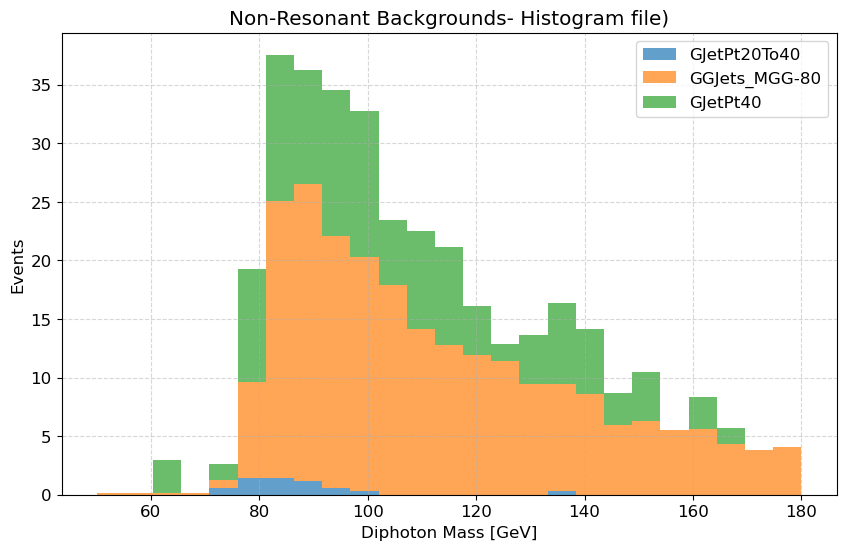

In [130]:
hist_data = []
bin_edges = None
labels = []

for file_path in filepaths_bkg_hist:
    with uproot.open(file_path) as f:
        # Find the histogram inside the "srbbgg" region folder
        folder_name = list(f.keys())[0].split(";")[0]  # first folder
        hist = f[f"{folder_name}/srbbgg/diphoton_mass"]  # adjust if branch name is different
        
        # Convert to numpy arrays
        counts, edges = hist.to_numpy()
        
        hist_data.append(counts)
        labels.append(folder_name)
        
        if bin_edges is None:
            bin_edges = edges  # use the first histogram's binning for all

# Make stacked histogram
plt.figure(figsize=(10,6))
plt.hist(
    [bin_edges[:-1]]*len(hist_data), 
    bins=bin_edges, 
    weights=hist_data, 
    stacked=True, 
    label=labels, 
    alpha=0.7
)
plt.xlabel("Diphoton Mass [GeV]")
plt.ylabel("Events")
plt.title("Non-Resonant Backgrounds- Histogram file)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [124]:
f = uproot.open("outputfiles/GJetPt40-histograms.root")  # replace with your file
print("Top-level keys:", list(f.keys()))

Top-level keys: ['GJetPt40;1', 'GJetPt40/preselection;1', 'GJetPt40/preselection/dibjet_mass;1', 'GJetPt40/preselection/diphoton_mass;1', 'GJetPt40/preselection/bbgg_mass;1', 'GJetPt40/preselection/dibjet_pt;1', 'GJetPt40/preselection/diphoton_pt;1', 'GJetPt40/preselection/bbgg_pt;1', 'GJetPt40/preselection/lead_pho_pt;1', 'GJetPt40/preselection/sublead_pho_pt;1', 'GJetPt40/preselection/bbgg_eta;1', 'GJetPt40/preselection/bbgg_phi;1', 'GJetPt40/preselection/lead_pho_eta;1', 'GJetPt40/preselection/lead_pho_phi;1', 'GJetPt40/preselection/sublead_pho_eta;1', 'GJetPt40/preselection/sublead_pho_phi;1', 'GJetPt40/preselection/diphoton_eta;1', 'GJetPt40/preselection/diphoton_phi;1', 'GJetPt40/preselection/dibjet_eta;1', 'GJetPt40/preselection/dibjet_phi;1', 'GJetPt40/preselection/lead_bjet_pt;1', 'GJetPt40/preselection/sublead_bjet_pt;1', 'GJetPt40/preselection/lead_bjet_eta;1', 'GJetPt40/preselection/lead_bjet_phi;1', 'GJetPt40/preselection/sublead_bjet_eta;1', 'GJetPt40/preselection/sublead

In [ ]:
# Replace 'YOUR_DIR_KEY' with the actual key you want to inspect
t = f["G"]
print("Keys inside directory:", list(t.keys()))


KeyInFileError: not found: 'YOUR_DIR_KEY' (with any cycle number)

    Available keys: 'GJetPt40;1', 'GJetPt40/srbbgg;1', 'GJetPt40/sideband;1', 'GJetPt40/srbbggMET;1', 'GJetPt40/crantibbgg;1', 'GJetPt40/crbbantigg;1', 'GJetPt40/idmva_presel;1', 'GJetPt40/selection;1', 'GJetPt40/srbbgg/n_jets;1'...

in file outputfiles/GJetPt40-histograms.root

In [27]:
mc_stack = Stack(
            *[
                get_histogram(
                    uproot_loaded_filename,
                    f"{mc_sample}/{hist_name}",
                    legend_dict[mc_sample],
                )
                for mc_sample in mc_samples
            ]
        )
        mc_stack.plot(ax=ax, stack=True, histtype="fill", flow="sum", sort="yield")


IndentationError: unexpected indent (954751706.py, line 11)

In [ ]:
get_histogram(file,)

In [ ]:
# Open the tree (adjust the name you see in keys())
# Check available branches
#print(tree.keys())
# List all keys (branch names)
tree = file["DiphotonTree"]["data_125_13TeV_NOTAG"]
all_keys = tree.keys()


KeyInFileError: not found: 'data_125_13TeV_NOTAG' (with any cycle number)

    Available keys: 'sideband;1', 'crantibbgg;1', 'crbbantigg;1', 'crantibbantigg;1', 'srbbgg;1', 'idmva_presel;1', 'idmva_sideband;1', 'selection;1', 'srbbggMET;1', 'preselection;1'

in file outputfiles/VHToGG-trees.root

In [38]:
eta_keys = [key for key in all_keys if "" in key]
print(eta_keys)

['lead_seediEtaOriX', 'lead_cutBased', 'lead_electronVeto', 'lead_hasConversionTracks', 'lead_isScEtaEB', 'lead_isScEtaEE', 'lead_mvaID_WP80', 'lead_mvaID_WP90', 'lead_pixelSeed', 'lead_seedGain', 'lead_electronIdx', 'lead_jetIdx', 'lead_seediPhiOriY', 'lead_vidNestedWPBitmap', 'lead_energyRaw', 'lead_eta', 'lead_haloTaggerMVAVal', 'lead_hoe_PUcorr', 'lead_pfChargedIsoPFPV', 'lead_pfPhoIso03', 'lead_pfRelIso03_all_quadratic', 'lead_pfRelIso03_chg_quadratic', 'lead_phi', 'lead_sipip', 'lead_x_calo', 'lead_y_calo', 'lead_z_calo', 'lead_genPartFlav', 'lead_genPartIdx', 'lead_electronIdxG', 'lead_genPartIdxG', 'lead_jetIdxG', 'lead_ScEta', 'lead_vetoEELeak', 'lead_pt_raw', 'lead_rho_smear', 'lead_energy', 'lead_pt', 'lead_mvaID_nano', 'lead_raw_r9', 'lead_r9', 'lead_raw_sieie', 'lead_sieie', 'lead_raw_etaWidth', 'lead_etaWidth', 'lead_raw_phiWidth', 'lead_phiWidth', 'lead_raw_sieip', 'lead_sieip', 'lead_raw_s4', 'lead_s4', 'lead_raw_hoe', 'lead_hoe', 'lead_raw_ecalPFClusterIso', 'lead_ecal

In [28]:
# Load dipho_mass and lead_eta into DataFrame
df = tree.arrays(["Res_lead_bjet_mass","Res_sublead_bjet_mass","Res_dijet_mass", "nonRes_dijet_mass", "VBF_dijet_pt", "lead_pt", "pt", "sublead_pt", "Res_lead_bjet_pt"], library="pd")

In [8]:
num=tree.num_entries

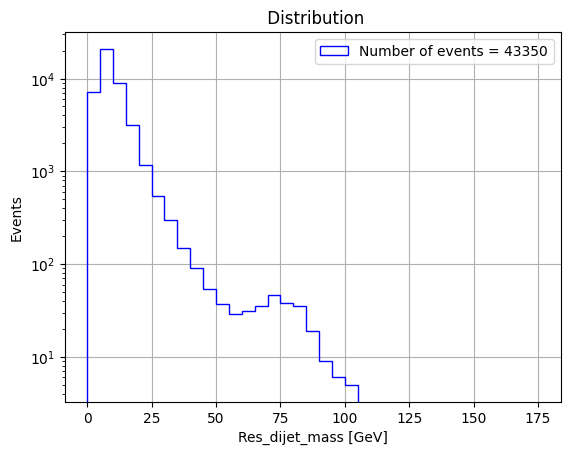

In [42]:
plt.hist(df["Res_lead_bjet_mass"], bins=35, range=(0,175), histtype="step", color="blue", label=f"Number of events = {num}")
plt.xlabel("Res_dijet_mass [GeV]")
plt.ylabel("Events")
#plt.ylim(0, 100000000)
plt.yscale('log')
plt.legend()
plt.title(" Distribution")
plt.grid(True)
plt.show()

In [15]:
print(type(file))

<class 'uproot.reading.ReadOnlyDirectory'>


In [16]:
keys = file.keys()
print(keys)

['DiphotonTree;1', 'DiphotonTree/data_125_13TeV_NOTAG;1']


In [42]:
events=file['Events']
print(type(events))

KeyInFileError: not found: 'Events' (with any cycle number)

    Available keys: 'DiphotonTree;1', 'DiphotonTree/data_125_13TeV_NOTAG;1'

in file VHToGG.root